# Optimizing Customer Support Agents for Cost and Quality

This cookbook walks through a practical optimization cycle for a tool-using customer support agent. It uses realistic mock support data and a deterministic simulation so the notebook can be run without API spend, while still showing the engineering tradeoffs customers should measure in production.

The use case is an e-commerce support assistant that can look up orders, retrieve support policies, open refund or replacement cases, and escalate to a human. The baseline agent is intentionally inefficient: broad instructions, oversized tool schemas, verbose tool outputs, high reasoning effort, no routing, no cache-friendly request shape, and synchronous background work.

By the end, you will have a repeatable pattern for:

- measuring token use, tool calls, latency, quality, escalation behavior, and estimated cost per ticket
- tightening prompts, output length, tool choice, tool payloads, and carried context
- routing predictable steps to smaller models while preserving high-risk quality
- making repeated support workflows cache-friendly
- moving non-customer-facing work to background, Batch API, or flex processing
- presenting a clear before/after that separates synchronous customer experience from offline follow-up work

The code defaults to dry-run mode. Set `RUN_LIVE_API_CALLS=true` and `OPENAI_API_KEY` to try the optional live Responses API helper cells.


## Use case and agent setup

This cookbook uses a customer support assistant for a fictional e-commerce company. The assistant handles common, high-volume support requests: order-status questions, damaged deliveries, refund eligibility, duplicate billing charges, and account-access problems. These requests are a good optimization target because some tickets are simple and repetitive, while others are policy-sensitive and require stronger reasoning or escalation.

The agent has access to a small set of connected tools that represent typical internal systems:

- `lookup_order`: retrieves shipment status, delivery age, item value, and billing signals
- `lookup_customer`: checks customer tier, region, and account verification state
- `lookup_policy`: retrieves support policy for shipping, refunds, billing, damaged delivery, or account access
- `create_refund_case`: opens a refund or replacement workflow when the policy allows it
- `escalate_to_human`: routes risky or ambiguous cases to a human support queue

The baseline agent is intentionally configured as one broad general-purpose agent. It sees every tool, receives oversized tool schemas and verbose tool payloads, uses a high-capability model for every step, and performs customer response drafting, internal QA, analytics tagging, and routing audit work in the same synchronous path. That setup mirrors common early agent prototypes: easy to build, but expensive and hard to reason about at scale.

Across the notebook, we keep the business workflow constant and optimize the agent implementation around it. The customer-facing path should classify the issue, call only the tools needed for that decision, apply the relevant policy, draft a concise response, and escalate when required. Follow-up work such as QA summaries and analytics tags can run later on cheaper processing paths.

## References

This notebook uses the current OpenAI platform shape as of August 10th, 2026.

- [Responses API reference](https://developers.openai.com/api/reference/resources/responses/methods/create): `max_output_tokens`, `reasoning`, `text.verbosity`, `tool_choice`, `prompt_cache_key`, `previous_response_id`, `context_management`, `truncation`, usage fields, and `service_tier`.
- [Function calling guide](https://developers.openai.com/api/docs/guides/function-calling): function tools, tool call outputs, `allowed_tools`, and passing reasoning/tool-call items forward.
- [Prompt caching guide](https://developers.openai.com/api/docs/guides/prompt-caching): stable prompt prefixes, cache keys, cache retention, and cached token accounting.
- [Cost optimization guide](https://developers.openai.com/api/docs/guides/cost-optimization): reduce requests, minimize tokens, select smaller models, use Batch and flex where appropriate.
- [Batch API guide](https://developers.openai.com/api/docs/guides/batch): asynchronous jobs with a `24h` completion window.
- [Model comparison](https://developers.openai.com/api/docs/models/compare): model prices, context windows, and endpoints used in the cost estimates below.

## Outline

1. Define success criteria and a small representative eval set.
2. Build the intentionally inefficient baseline support agent.
3. Measure baseline cost, tokens, quality, latency, and tool calls.
4. Apply prompt, output, tool, and context controls.
5. Route simple steps to smaller models.
6. Restructure requests for prompt caching.
7. Split real-time and follow-up work.
8. Add monitoring, evals, and guardrails.

## Setup

Install or upgrade the packages if needed:

```bash
pip install --upgrade openai pandas matplotlib
```

The notebook does not call the API by default. To run the optional live API cells:

```bash
export OPENAI_API_KEY=...
export RUN_LIVE_API_CALLS=true
```

In [1]:
import json
import math
import os
import statistics
import textwrap
import time
from dataclasses import dataclass
from typing import Any

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print

try:
    from openai import OpenAI
except ImportError:
    OpenAI = None

RUN_LIVE_API_CALLS = (
    OpenAI is not None
    and bool(os.environ.get("OPENAI_API_KEY"))
    and os.environ.get("RUN_LIVE_API_CALLS", "false").lower() == "true"
)

client = OpenAI() if RUN_LIVE_API_CALLS else None

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
print("RUN_LIVE_API_CALLS =", RUN_LIVE_API_CALLS)

RUN_LIVE_API_CALLS = False


## Success criteria and constraints

Cost savings only matter when the support experience still clears the quality bar. In this notebook, a variant must preserve or improve:

- resolution correctness: the answer uses the right order, customer, and policy facts
- policy compliance: refunds, replacements, billing issues, and account access follow support policy
- escalation correctness: high-risk or ambiguous cases go to a human
- action correctness: refund/replacement cases are opened only when the policy allows them
- concise customer response: no internal reasoning, raw tool data, or unnecessary policy dumps
- latency and cost: p50/p95 latency improve and total cost per ticket decreases

The eval set is intentionally small so the mechanics are easy to inspect. In production, replace it with a stratified sample from real tickets, meaning the sample deliberately includes the main slices of your queue such as intents, risk levels, languages, regions, customer tiers, and edge cases. Keep a holdout set, and gate every optimization on quality and safety metrics before accepting cost savings.


## Simulation contract

This notebook is a demo, so the default path uses mock data and modeled metrics instead of live API calls. The simulation is designed to be realistic enough to teach the optimization loop, but it is not a benchmark of production performance.

What is measured directly in dry-run mode:

- serialized prompt, tool schema, tool output, customer message, and response lengths
- expected vs actual tool selection, action selection, and escalation behavior
- estimated cost using the model price table in this notebook

What is modeled:

- reasoning tokens, based on ticket difficulty, model choice, and reasoning effort
- latency, based on model class, token volume, and tool-call count
- prompt cache hits, based on stable-prefix size and cache eligibility
- quality score, derived from correctness, policy compliance, action correctness, concision, and unnecessary tool use

For a real deployment, replace the simulated traces with stored production traces or eval runs that include actual `usage`, latency, tool calls, model routing decisions, and judge results.


## Optimization knobs 

| Knob | Inefficient baseline | Optimized pattern | Primary metric |
|---|---|---|---|
| Prompt and output | Broad "be thorough" instructions and long answers | Specific task rules, concise response contract, `text.verbosity="low"`, capped output | Output tokens, concision, quality |
| Reasoning effort | High reasoning for every ticket | Low/minimal for routine work, higher only for high-risk decisions | Reasoning tokens, latency |
| Tool surface | All tools exposed for every request | Full stable tool list plus `tool_choice.allowed_tools` per task | Tool calls, cacheability |
| Tool schemas | Verbose descriptions and broad payload expectations | Small schemas with only decision-critical arguments | Input tokens |
| Tool payloads | Raw CRM, carrier, audit, and appendix blobs | Slim fields needed for the next decision | Tool output tokens |
| Model routing | One large model for all steps | Nano for triage/tags, mini for routine resolution, full model for high-risk cases | Cost, latency, escalation accuracy |
| Prompt caching | Volatile ticket data mixed into the prefix | Stable instructions, tools, policy framing, and schema first; ticket data last | Cached input tokens, cost |
| Workflow split | QA, analytics, summaries, and audits in the customer path | Customer resolution sync; QA/tags/reporting async via background, flex, or Batch | p50 latency, synchronous cost |
| Guardrails and evals | Informal spot checks | Deterministic checks plus judge schema for live traces | Regression rate, safety pass rate |


## Sample evaluation set

This small sample eval set gives the notebook concrete tickets, expected tools, expected actions, escalation labels, and forbidden claims to score each optimization round.


In [2]:
EVAL_SET = [
    {
        "ticket_id": "T-001",
        "customer_id": "C-100",
        "message": "Where is order O-1001? It was supposed to arrive yesterday.",
        "intent": "order_status",
        "order_id": "O-1001",
        "risk": "low",
        "difficulty": "simple_lookup",
        "must_escalate": False,
        "expected_policy": "shipping",
        "expected_tools": ["lookup_order"],
        "expected_action": "provide_status_eta",
        "expected_resolution_type": "resolved",
        "expected_customer_response_contains": ["in transit", "tomorrow"],
        "forbidden_response_claims": ["refund completed", "replacement opened"],
    },
    {
        "ticket_id": "T-002",
        "customer_id": "C-200",
        "message": "My blender arrived cracked. Order O-1002. Can you replace it?",
        "intent": "damaged_delivery",
        "order_id": "O-1002",
        "risk": "medium",
        "difficulty": "routine_policy",
        "must_escalate": False,
        "expected_policy": "damaged_delivery",
        "expected_tools": ["lookup_order", "lookup_policy"],
        "expected_action": "request_photo_then_offer_replacement",
        "expected_resolution_type": "resolved_next_step",
        "expected_customer_response_contains": ["photo", "replacement"],
        "forbidden_response_claims": ["refund completed", "no photo needed"],
    },
    {
        "ticket_id": "T-003",
        "customer_id": "C-300",
        "message": "I want a refund for order O-1003. It arrived but I changed my mind.",
        "intent": "refund_eligibility",
        "order_id": "O-1003",
        "risk": "medium",
        "difficulty": "routine_policy",
        "must_escalate": False,
        "expected_policy": "refunds",
        "expected_tools": ["lookup_order", "lookup_policy", "create_refund_case"],
        "expected_action": "open_refund_case",
        "expected_resolution_type": "case_opened",
        "expected_customer_response_contains": ["refund case", "within 30 days"],
        "forbidden_response_claims": ["refund completed", "human review required"],
    },
    {
        "ticket_id": "T-004",
        "customer_id": "C-400",
        "message": "I was charged twice for order O-1004. Please fix this.",
        "intent": "billing_issue",
        "order_id": "O-1004",
        "risk": "medium",
        "difficulty": "sensitive_policy",
        "must_escalate": True,
        "expected_policy": "billing",
        "expected_tools": ["lookup_order", "lookup_policy", "escalate_to_human"],
        "expected_action": "escalate_billing_review",
        "expected_resolution_type": "escalated",
        "expected_customer_response_contains": ["billing", "review"],
        "forbidden_response_claims": ["refund completed", "duplicate charge reversed"],
    },
    {
        "ticket_id": "T-005",
        "customer_id": "C-500",
        "message": "I cannot get into my account and my phone number changed.",
        "intent": "account_access",
        "order_id": None,
        "risk": "high",
        "difficulty": "account_security",
        "must_escalate": True,
        "expected_policy": "account_access",
        "expected_tools": ["lookup_customer", "lookup_policy", "escalate_to_human"],
        "expected_action": "escalate_account_security",
        "expected_resolution_type": "escalated",
        "expected_customer_response_contains": ["account security", "verification"],
        "forbidden_response_claims": ["phone number changed", "password reset completed"],
    },
    {
        "ticket_id": "T-006",
        "customer_id": "C-600",
        "message": "I want a refund for order O-1005, but tracking says delivered 45 days ago.",
        "intent": "refund_dispute",
        "order_id": "O-1005",
        "risk": "high",
        "difficulty": "outside_policy_window",
        "must_escalate": True,
        "expected_policy": "refunds",
        "expected_tools": ["lookup_order", "lookup_policy", "escalate_to_human"],
        "expected_action": "escalate_refund_review",
        "expected_resolution_type": "escalated",
        "expected_customer_response_contains": ["human review", "outside"],
        "forbidden_response_claims": ["refund completed", "refund case opened"],
    },
    {
        "ticket_id": "T-007",
        "customer_id": "C-700",
        "message": "Tracking says order O-1006 was delivered today, but I do not see it at my door.",
        "intent": "delivered_not_received",
        "order_id": "O-1006",
        "risk": "medium",
        "difficulty": "routine_policy",
        "must_escalate": False,
        "expected_policy": "shipping",
        "expected_tools": ["lookup_order", "lookup_policy"],
        "expected_action": "start_delivery_trace_steps",
        "expected_resolution_type": "resolved_next_step",
        "expected_customer_response_contains": ["delivered today", "check", "carrier"],
        "forbidden_response_claims": ["refund completed", "replacement opened"],
    },
    {
        "ticket_id": "T-008",
        "customer_id": "C-800",
        "message": "The espresso machine in order O-1007 arrived shattered. It was over $1,000 and I need a refund now.",
        "intent": "high_value_damage",
        "order_id": "O-1007",
        "risk": "high",
        "difficulty": "high_value_policy",
        "must_escalate": True,
        "expected_policy": "damaged_delivery",
        "expected_tools": ["lookup_order", "lookup_policy", "escalate_to_human"],
        "expected_action": "escalate_high_value_damage",
        "expected_resolution_type": "escalated",
        "expected_customer_response_contains": ["human review", "photo"],
        "forbidden_response_claims": ["refund completed", "replacement shipped"],
    },
    {
        "ticket_id": "T-009",
        "customer_id": "C-900",
        "message": "I need to return order O-1008. The headphones are unopened and arrived two weeks ago.",
        "intent": "refund_eligibility",
        "order_id": "O-1008",
        "risk": "low",
        "difficulty": "routine_policy",
        "must_escalate": False,
        "expected_policy": "refunds",
        "expected_tools": ["lookup_order", "lookup_policy", "create_refund_case"],
        "expected_action": "open_refund_case",
        "expected_resolution_type": "case_opened",
        "expected_customer_response_contains": ["refund case", "eligible"],
        "forbidden_response_claims": ["human review required", "refund completed"],
    },
    {
        "ticket_id": "T-010",
        "customer_id": "C-1000",
        "message": "I lost access to my account and cannot verify the old email address.",
        "intent": "account_access",
        "order_id": None,
        "risk": "high",
        "difficulty": "account_security",
        "must_escalate": True,
        "expected_policy": "account_access",
        "expected_tools": ["lookup_customer", "lookup_policy", "escalate_to_human"],
        "expected_action": "escalate_account_security",
        "expected_resolution_type": "escalated",
        "expected_customer_response_contains": ["account security", "verification"],
        "forbidden_response_claims": ["email changed", "account restored"],
    },
]

pd.DataFrame(EVAL_SET)[
    [
        "ticket_id",
        "intent",
        "risk",
        "difficulty",
        "expected_tools",
        "expected_action",
        "must_escalate",
    ]
]


,ticket_id,intent,risk,difficulty,expected_tools,expected_action,must_escalate
0,T-001,order_status,low,simple_lookup,[lookup_order],provide_status_eta,False
1,T-002,damaged_delivery,medium,routine_policy,"[lookup_order, lookup_policy]",request_photo_then_offer_replacement,False
2,T-003,refund_eligibility,medium,routine_policy,"[lookup_order, lookup_policy, create_refund_case]",open_refund_case,False
3,T-004,billing_issue,medium,sensitive_policy,"[lookup_order, lookup_policy, escalate_to_human]",escalate_billing_review,True
4,T-005,account_access,high,account_security,"[lookup_customer, lookup_policy, escalate_to_h...",escalate_account_security,True
5,T-006,refund_dispute,high,outside_policy_window,"[lookup_order, lookup_policy, escalate_to_human]",escalate_refund_review,True
6,T-007,delivered_not_received,medium,routine_policy,"[lookup_order, lookup_policy]",start_delivery_trace_steps,False
7,T-008,high_value_damage,high,high_value_policy,"[lookup_order, lookup_policy, escalate_to_human]",escalate_high_value_damage,True
8,T-009,refund_eligibility,low,routine_policy,"[lookup_order, lookup_policy, create_refund_case]",open_refund_case,False
9,T-010,account_access,high,account_security,"[lookup_customer, lookup_policy, escalate_to_h...",escalate_account_security,True


## Support data and tools

A typical support agent has at least two connected tools: one operational system and one policy source. Here we use four local Python functions to stand in for internal systems.

The baseline returns oversized payloads to show how tool outputs can dominate input tokens. Later rounds switch to minimal payloads that include only fields needed for the next decision and customer response.

In [3]:
INTERNAL_POLICY_APPENDIX = (
    "Internal appendix: historical exception notes, vendor mappings, warehouse event definitions, "
    "billing processor flags, carrier SLA tables, outdated macro text, and audit metadata. "
    * 45
)

ORDERS = {
    "O-1001": {
        "order_id": "O-1001",
        "status": "in_transit",
        "carrier": "UPS",
        "eta": "tomorrow",
        "items": [{"sku": "MUG-11", "name": "Ceramic mug", "price": 18.0}],
        "delivered_days_ago": None,
        "payment_status": "paid_once",
        "events": ["packed", "carrier_pickup", "regional_delay", "in_transit"],
    },
    "O-1002": {
        "order_id": "O-1002",
        "status": "delivered",
        "carrier": "FedEx",
        "eta": None,
        "items": [{"sku": "BLD-42", "name": "Countertop blender", "price": 89.0}],
        "delivered_days_ago": 2,
        "payment_status": "paid_once",
        "events": ["packed", "carrier_pickup", "delivered", "damage_claim_available"],
    },
    "O-1003": {
        "order_id": "O-1003",
        "status": "delivered",
        "carrier": "USPS",
        "eta": None,
        "items": [{"sku": "SHOE-9", "name": "Running shoes", "price": 120.0}],
        "delivered_days_ago": 8,
        "payment_status": "paid_once",
        "events": ["packed", "delivered", "standard_return_window"],
    },
    "O-1004": {
        "order_id": "O-1004",
        "status": "delivered",
        "carrier": "UPS",
        "eta": None,
        "items": [{"sku": "COAT-3", "name": "Rain coat", "price": 150.0}],
        "delivered_days_ago": 4,
        "payment_status": "duplicate_charge_detected",
        "events": ["packed", "delivered", "billing_review_required"],
    },
    "O-1005": {
        "order_id": "O-1005",
        "status": "delivered",
        "carrier": "DHL",
        "eta": None,
        "items": [{"sku": "CAM-7", "name": "Camera kit", "price": 650.0}],
        "delivered_days_ago": 45,
        "payment_status": "paid_once",
        "events": ["packed", "delivered", "outside_standard_refund_window"],
    },
    "O-1006": {
        "order_id": "O-1006",
        "status": "delivered",
        "carrier": "UPS",
        "eta": None,
        "items": [{"sku": "LAMP-8", "name": "Desk lamp", "price": 46.0}],
        "delivered_days_ago": 0,
        "payment_status": "paid_once",
        "events": ["packed", "delivered", "proof_of_delivery_uploaded"],
    },
    "O-1007": {
        "order_id": "O-1007",
        "status": "delivered",
        "carrier": "FedEx",
        "eta": None,
        "items": [{"sku": "ESP-99", "name": "Prosumer espresso machine", "price": 1250.0}],
        "delivered_days_ago": 1,
        "payment_status": "paid_once",
        "events": ["packed", "delivered", "damage_claim_available", "high_value_item"],
    },
    "O-1008": {
        "order_id": "O-1008",
        "status": "delivered",
        "carrier": "USPS",
        "eta": None,
        "items": [{"sku": "HP-21", "name": "Wireless headphones", "price": 75.0}],
        "delivered_days_ago": 14,
        "payment_status": "paid_once",
        "events": ["packed", "delivered", "standard_return_window", "unopened_customer_claim"],
    },
}

CUSTOMERS = {
    "C-100": {"tier": "standard", "region": "CA", "verified": True, "lifetime_value": 240},
    "C-200": {"tier": "plus", "region": "NY", "verified": True, "lifetime_value": 920},
    "C-300": {"tier": "standard", "region": "WA", "verified": True, "lifetime_value": 410},
    "C-400": {"tier": "standard", "region": "IL", "verified": True, "lifetime_value": 310},
    "C-500": {"tier": "plus", "region": "TX", "verified": False, "lifetime_value": 1250},
    "C-600": {"tier": "standard", "region": "CA", "verified": True, "lifetime_value": 700},
    "C-700": {"tier": "standard", "region": "OR", "verified": True, "lifetime_value": 155},
    "C-800": {"tier": "plus", "region": "FL", "verified": True, "lifetime_value": 2800},
    "C-900": {"tier": "standard", "region": "MA", "verified": True, "lifetime_value": 190},
    "C-1000": {"tier": "standard", "region": "AZ", "verified": False, "lifetime_value": 80},
}

POLICIES = {
    "shipping": "If an order is in transit with a carrier delay, provide status, ETA, and tracking next steps. If tracking says delivered today but the customer cannot find it, ask them to check common delivery locations, verify the address, and start carrier trace steps if it remains missing. Do not refund solely for a short carrier delay or same-day delivered-not-received report.",
    "damaged_delivery": "If damage is reported within 7 days of delivery, ask for a photo and offer replacement or refund after evidence is collected. High-value damaged items over $1,000 require human review before promising a refund or replacement.",
    "refunds": "Standard refunds are eligible within 30 days of delivery for most unopened or returnable items. Orders over 30 days old, high-value disputes, or ambiguous return condition require human review before any refund promise.",
    "billing": "Duplicate charges require billing review. A support agent may acknowledge the issue and escalate, but must not promise a completed refund until billing verifies it.",
    "account_access": "If account recovery identity is not verified, escalate to account security. Do not change credentials, email addresses, or phone numbers in chat.",
}

def lookup_order(order_id: str, payload: str = "slim") -> dict[str, Any]:
    order = ORDERS.get(order_id.upper())
    if not order:
        return {"found": False, "order_id": order_id}
    if payload == "verbose":
        return {
            "found": True,
            "order": order,
            "warehouse_events": [{"event": event, "source": "wms", "debug": INTERNAL_POLICY_APPENDIX[:300]} for event in order["events"]],
            "carrier_payload": {
                "carrier": order["carrier"],
                "raw_tracking_blob": INTERNAL_POLICY_APPENDIX,
            },
            "payment_processor_payload": {
                "status": order["payment_status"],
                "raw_processor_notes": INTERNAL_POLICY_APPENDIX[:1200],
            },
            "internal_notes": INTERNAL_POLICY_APPENDIX,
        }
    return {
        "found": True,
        "order_id": order["order_id"],
        "status": order["status"],
        "carrier": order["carrier"],
        "eta": order["eta"],
        "delivered_days_ago": order["delivered_days_ago"],
        "payment_status": order["payment_status"],
        "item_value": sum(item["price"] for item in order["items"]),
        "events": [event for event in order["events"] if event in {"regional_delay", "damage_claim_available", "billing_review_required", "outside_standard_refund_window", "proof_of_delivery_uploaded", "high_value_item", "standard_return_window"}],
    }

def lookup_customer(customer_id: str, payload: str = "slim") -> dict[str, Any]:
    customer = CUSTOMERS.get(customer_id)
    if not customer:
        return {"found": False, "customer_id": customer_id}
    if payload == "verbose":
        return {
            "found": True,
            "customer_id": customer_id,
            "profile": customer,
            "all_recent_order_ids": list(ORDERS.keys()),
            "crm_audit_log": INTERNAL_POLICY_APPENDIX,
        }
    return {"found": True, "customer_id": customer_id, **customer}

def lookup_policy(topic: str, payload: str = "slim") -> dict[str, Any]:
    policy = POLICIES.get(topic)
    if not policy:
        return {"found": False, "topic": topic}
    if payload == "verbose":
        return {
            "found": True,
            "topic": topic,
            "policy": policy,
            "appendix": INTERNAL_POLICY_APPENDIX,
            "all_policy_topics": POLICIES,
        }
    return {"found": True, "topic": topic, "policy": policy}

def create_refund_case(order_id: str, reason: str) -> dict[str, Any]:
    return {"case_id": f"RF-{order_id}", "order_id": order_id, "status": "opened", "reason": reason}

def escalate_to_human(ticket_id: str, reason: str) -> dict[str, Any]:
    return {"ticket_id": ticket_id, "queue": "human_support", "priority": "normal", "reason": reason}


In [4]:
def function_schema(name: str, description: str, properties: dict[str, Any], required: list[str]) -> dict[str, Any]:
    return {
        "type": "function",
        "name": name,
        "description": description,
        "parameters": {
            "type": "object",
            "properties": properties,
            "required": required,
            "additionalProperties": False,
        },
        "strict": True,
    }

VERBOSE_TOOLS = [
    function_schema(
        "lookup_customer",
        "Retrieve the complete customer CRM profile, including audit metadata, tiering data, account verification state, related orders, and any internal support notes that could possibly help.",
        {"customer_id": {"type": "string", "description": "The customer identifier from the ticket."}},
        ["customer_id"],
    ),
    function_schema(
        "lookup_order",
        "Retrieve the complete order record, shipment timeline, billing fields, warehouse event payloads, raw carrier diagnostics, and internal debug data.",
        {"order_id": {"type": "string", "description": "The order identifier, such as O-1001."}},
        ["order_id"],
    ),
    function_schema(
        "lookup_policy",
        "Retrieve the full policy topic, all related appendix material, exception examples, internal macros, and neighboring policy topics.",
        {"topic": {"type": "string", "enum": list(POLICIES), "description": "Policy topic to retrieve."}},
        ["topic"],
    ),
    function_schema(
        "create_refund_case",
        "Open a refund case in the back office system. This should be used for any refund or replacement possibility, even when a human review might be required.",
        {
            "order_id": {"type": "string"},
            "reason": {"type": "string"},
        },
        ["order_id", "reason"],
    ),
    function_schema(
        "escalate_to_human",
        "Escalate a ticket to a human support agent when the issue is ambiguous, policy-sensitive, high value, account-security related, or otherwise risky.",
        {
            "ticket_id": {"type": "string"},
            "reason": {"type": "string"},
        },
        ["ticket_id", "reason"],
    ),
]

SLIM_TOOLS = [
    function_schema(
        "lookup_customer",
        "Fetch minimal customer verification and support tier fields.",
        {"customer_id": {"type": "string"}},
        ["customer_id"],
    ),
    function_schema(
        "lookup_order",
        "Fetch order status, delivery age, payment status, and item value.",
        {"order_id": {"type": "string"}},
        ["order_id"],
    ),
    function_schema(
        "lookup_policy",
        "Fetch the policy needed for the current support decision.",
        {"topic": {"type": "string", "enum": list(POLICIES)}},
        ["topic"],
    ),
    function_schema(
        "create_refund_case",
        "Open a refund or replacement case only after policy eligibility is established.",
        {"order_id": {"type": "string"}, "reason": {"type": "string"}},
        ["order_id", "reason"],
    ),
    function_schema(
        "escalate_to_human",
        "Escalate a ticket that requires human review.",
        {"ticket_id": {"type": "string"}, "reason": {"type": "string"}},
        ["ticket_id", "reason"],
    ),
]

def allowed_tool_choice(names: list[str], mode: str = "auto") -> dict[str, Any]:
    return {
        "type": "allowed_tools",
        "mode": mode,
        "tools": [{"type": "function", "name": name} for name in names],
    }

print("Verbose tool schema tokens:", math.ceil(len(json.dumps(VERBOSE_TOOLS)) / 4))
print("Slim tool schema tokens:", math.ceil(len(json.dumps(SLIM_TOOLS)) / 4))

Verbose tool schema tokens: 550
Slim tool schema tokens: 397


## Baseline architecture

The bad baseline does too much in one synchronous path.

```mermaid
flowchart LR
    A["Customer message"] --> B["One general agent on strongest model"]
    B --> C["Customer lookup"]
    B --> D["Order lookup"]
    B --> E["Policy lookup"]
    B --> F["Refund or escalation tools"]
    B --> G["Customer response"]
    B --> H["QA summary"]
    B --> I["Analytics tagging"]
    B --> J["Routing audit"]
```

Common waste patterns in this baseline:

- broad instructions and "be thorough" language
- high reasoning effort for every ticket
- all tools exposed for every task
- large tool schemas and verbose tool payloads
- long customer answers
- internal QA, analytics, and audit work in the customer-facing path

In [5]:
BAD_BASELINE_PROMPT = textwrap.dedent(
    '''
    You are a comprehensive customer support super-agent for an e-commerce company.

    Always be extremely thorough. Before answering, gather as much context as possible from
    customer, order, policy, refund, escalation, and internal support systems. Prefer using tools
    even when the answer may already be apparent. Include helpful background and explain your
    reasoning to the customer in detail so they understand every step.

    You are also responsible for post-resolution QA, analytics tags, support summaries, policy-gap
    mining, and escalation audits before you respond to the customer.

    If there is any uncertainty, call more tools. If a policy might be relevant, retrieve the policy.
    If an order might be relevant, retrieve the order. If customer history might be relevant, retrieve
    the customer profile.
    '''
).strip()

CONTROLLED_PROMPT = textwrap.dedent(
    '''
    Role: E-commerce support assistant.

    Goal: Resolve routine support tickets with the fewest necessary tool calls while preserving policy correctness.

    Tool rules:
    - Use only tools required for the current decision.
    - Order status: order lookup only.
    - Damaged delivery or refund: order lookup plus the relevant policy.
    - Billing duplicate charge: order lookup plus billing policy, then escalate.
    - Account access with unverified identity: customer lookup plus account policy, then escalate.

    Response rules:
    - Give the customer the outcome and next step.
    - Do not expose internal reasoning, raw tool data, audit notes, or policy text.
    - Keep the customer-facing answer under 120 words unless escalation legally requires more detail.
    '''
).strip()

STABLE_SUPPORT_PREFIX = textwrap.dedent(
    '''
    Role: E-commerce support assistant.
    Constraints: Be concise, policy-compliant, and explicit about next steps. Do not disclose internal data.
    Escalate: duplicate charges, account access without verification, high-value disputes, and refunds outside the window.
    Output shape: customer_message, resolution_type, escalate, internal_tags.
    Tool contract: tool definitions are stable across requests; restrict callable tools with tool_choice.allowed_tools.
    Version: support-agent-optimization-v1.
    '''
).strip()

## Metrics helpers

The live API returns usage fields such as `input_tokens`, `output_tokens`, `total_tokens`, `input_tokens_details.cached_tokens`, and `output_tokens_details.reasoning_tokens`. In dry-run mode we estimate tokens from serialized text and use a simple deterministic cost model.

Codex can you update the prices and date accordingly? The rates below are copied from the model comparison page on April 21, 2026. Check the [pricing page](https://developers.openai.com/api/docs/pricing) before publishing or using this in production.

In [6]:
MODEL_PRICES_USD_PER_1M = {
    "gpt-5.4": {"input": 2.50, "cached_input": 0.25, "output": 15.00},
    "gpt-5.4-mini": {"input": 0.75, "cached_input": 0.08, "output": 4.50},
    "gpt-5.4-nano": {"input": 0.20, "cached_input": 0.02, "output": 1.25},
}

def approx_tokens(value: Any) -> int:
    if value is None:
        return 0
    if not isinstance(value, str):
        value = json.dumps(value, sort_keys=True)
    return max(1, math.ceil(len(value) / 4))

def estimate_cost_usd(model: str, input_tokens: int, output_tokens: int, cached_input_tokens: int = 0, discount: float = 1.0) -> float:
    rates = MODEL_PRICES_USD_PER_1M[model]
    cached = min(cached_input_tokens, input_tokens)
    uncached = max(input_tokens - cached, 0)
    cost = (
        uncached * rates["input"]
        + cached * rates["cached_input"]
        + output_tokens * rates["output"]
    ) / 1_000_000
    return cost * discount

def response_usage_dict(response: Any) -> dict[str, int]:
    usage = getattr(response, "usage", None)
    if usage is None:
        return {
            "input_tokens": 0,
            "cached_tokens": 0,
            "output_tokens": 0,
            "reasoning_tokens": 0,
            "total_tokens": 0,
        }
    input_details = getattr(usage, "input_tokens_details", None)
    output_details = getattr(usage, "output_tokens_details", None)
    input_tokens = getattr(usage, "input_tokens", 0) or 0
    output_tokens = getattr(usage, "output_tokens", 0) or 0
    cached_tokens = getattr(input_details, "cached_tokens", 0) if input_details else 0
    reasoning_tokens = getattr(output_details, "reasoning_tokens", 0) if output_details else 0
    return {
        "input_tokens": input_tokens,
        "cached_tokens": cached_tokens or 0,
        "output_tokens": output_tokens,
        "reasoning_tokens": reasoning_tokens or 0,
        "total_tokens": getattr(usage, "total_tokens", input_tokens + output_tokens) or input_tokens + output_tokens,
    }

## Dry-run simulation

The dry-run harness models the effects we expect from each optimization while still deriving the key numbers from the mocked tickets, tool schemas, tool payloads, response text, and expected business actions.

It captures:

- fewer and smaller tool payloads
- shorter customer-facing outputs
- less reasoning effort on routine tasks
- model routing to mini or nano where appropriate
- cached input tokens only when the stable prefix is large enough to be cache-eligible
- background work removed from the synchronous customer response path while still counting its async cost
- quality changes from action correctness, policy compliance, escalation correctness, concision, and unnecessary tool use

One important demo assumption: the optimized variants use an application router that maps each mock ticket to the relevant support path before restricting tools. In production, that router can be deterministic business logic, a small classifier, or a hybrid, and it needs its own evals because routing errors can erase cost savings.

Replace the simulated traces with production traces when you have them. The important part is the shape of the measurement loop, not the toy numbers.


In [7]:
VARIANT_ORDER = [
    "00_bad_baseline",
    "01_prompt_tool_context_controls",
    "02_model_routing",
    "03_prompt_caching",
    "04_split_workflow",
]

VARIANT_LABELS = {
    "00_bad_baseline": "Bad baseline",
    "01_prompt_tool_context_controls": "Round 1: controls",
    "02_model_routing": "Round 2: routing",
    "03_prompt_caching": "Round 3: caching",
    "04_split_workflow": "Round 4: split workflow",
}

CACHE_ELIGIBILITY_MIN_TOKENS = 1024
CONCISE_OUTPUT_TOKEN_LIMIT = 120
ASYNC_BATCH_DISCOUNT = 0.50  # Demo assumption. Check current Batch/flex pricing before production use.

STABLE_POLICY_DIGEST = textwrap.dedent(
    '''
    Stable support playbook digest:
    - Shipping delays: provide status, ETA, and tracking next steps; do not refund solely for short carrier delays.
    - Delivered-not-received: verify delivery details, ask the customer to check common locations, and start carrier trace steps when appropriate.
    - Damaged delivery: request photo evidence before offering replacement or refund; high-value damaged items require human review.
    - Refunds: standard returnable items are eligible within 30 days; outside-window or high-value disputes require human review.
    - Billing: duplicate-charge reports require billing review; acknowledge and escalate, but do not promise a completed refund.
    - Account access: when identity is not verified, escalate to account security; do not change credentials or contact information in chat.
    - Customer messages must be concise, policy-compliant, and explicit about next steps.
    - Internal notes, raw carrier payloads, CRM audit logs, and policy appendices must never be exposed to the customer.
    '''
).strip()

# Repeat the stable digest to mimic a real support playbook plus stable tool/schema prefix.
# This makes prompt caching eligible without adding volatile ticket-specific content.
CACHE_FRIENDLY_PROMPT = STABLE_SUPPORT_PREFIX + "\n\n" + "\n".join([STABLE_POLICY_DIGEST] * 5)

DIFFICULTY_REASONING_BASE = {
    "simple_lookup": 45,
    "routine_policy": 70,
    "sensitive_policy": 95,
    "account_security": 125,
    "outside_policy_window": 120,
    "high_value_policy": 135,
}

MODEL_LATENCY_BASE = {
    "gpt-5.4": 0.95,
    "gpt-5.4-mini": 0.35,
    "gpt-5.4-nano": 0.16,
}

ALL_TOOL_NAMES = [tool["name"] for tool in SLIM_TOOLS]


def tools_for_ticket(ticket: dict[str, Any], variant: str) -> list[str]:
    if variant == "00_bad_baseline":
        return ALL_TOOL_NAMES.copy()
    return ticket["expected_tools"].copy()


def route_resolution_model(ticket: dict[str, Any], variant: str) -> str:
    if variant in {"00_bad_baseline", "01_prompt_tool_context_controls"}:
        return "gpt-5.4"
    if ticket["risk"] == "high":
        return "gpt-5.4"
    return "gpt-5.4-mini"


def action_for_ticket(ticket: dict[str, Any], variant: str) -> str:
    if variant != "00_bad_baseline":
        return ticket["expected_action"]

    # The baseline is intentionally inefficient and sometimes over- or under-acts.
    baseline_mistakes = {
        "damaged_delivery": "open_replacement_without_photo",
        "refund_eligibility": "escalate_refund_review",
        "high_value_damage": "promise_refund_high_value_damage",
    }
    return baseline_mistakes.get(ticket["intent"], ticket["expected_action"])


def action_is_escalation(action: str) -> bool:
    return action.startswith("escalate_")


def simulated_customer_response(ticket: dict[str, Any], variant: str, action: str) -> str:
    order_id = ticket.get("order_id") or "your account"
    if variant == "00_bad_baseline":
        return textwrap.dedent(
            f'''
            I reviewed your message for ticket {ticket['ticket_id']} and checked the customer profile, order system,
            policy library, refund workflow, escalation queue, carrier events, billing signals, and internal audit notes.
            Based on the available context for {order_id}, the detected intent is {ticket['intent']} and the risk level is
            {ticket['risk']}. I also compared this against the {ticket['expected_policy']} policy and related internal
            exceptions. My working action is `{action}`. I am including this detail so you understand each step, but some
            of these details are internal operational records. The next step is to proceed according to that action, and
            we may need additional review if any policy exception applies.
            '''
        ).strip()

    if action == "provide_status_eta":
        return "Your order is still in transit and the latest ETA is tomorrow. The carrier shows a short delay, so no refund is due yet. Please check the tracking link again tomorrow."
    if action == "request_photo_then_offer_replacement":
        return "I can help with a replacement. Please reply with a photo of the cracked blender and packaging, and we can start the replacement or refund process under the damaged-delivery policy."
    if action == "open_refund_case":
        return f"This order is within the standard return window, so I opened a refund case for {order_id}. You will receive return instructions and the refund will be processed after the return is received."
    if action == "escalate_billing_review":
        return "I found a duplicate-charge signal and sent this to billing review. The billing team will verify the charge before any refund is confirmed."
    if action == "escalate_account_security":
        return "I cannot change account details until identity is verified. I escalated this to account security so they can help you recover access safely."
    if action == "escalate_refund_review":
        return "This refund request is outside the standard window, so I escalated it for human review. A specialist will check whether an exception applies."
    if action == "start_delivery_trace_steps":
        return "Tracking shows the order was delivered today. Please check common delivery spots and confirm the address; if it is still missing, we can start carrier trace steps."
    if action == "escalate_high_value_damage":
        return "I am sorry the item arrived damaged. Because this is a high-value item, I escalated it for human review. Please attach photos of the item and packaging."
    return "I reviewed the ticket and sent it to the right support path."


def simulated_reasoning_tokens(ticket: dict[str, Any], variant: str, model: str, tool_count: int) -> int:
    base = DIFFICULTY_REASONING_BASE[ticket["difficulty"]]
    if variant == "00_bad_baseline":
        return int(base + 260 + tool_count * 28)
    if variant == "01_prompt_tool_context_controls":
        return int(base * 0.72 + tool_count * 10)
    if variant in {"02_model_routing", "03_prompt_caching"}:
        model_factor = 0.62 if model == "gpt-5.4-mini" else 0.82
        return int(base * model_factor + tool_count * 8)
    model_factor = 0.55 if model == "gpt-5.4-mini" else 0.74
    return int(base * model_factor + tool_count * 6)


def prompt_for_variant(variant: str) -> str:
    if variant == "00_bad_baseline":
        return BAD_BASELINE_PROMPT
    if variant in {"03_prompt_caching", "04_split_workflow"}:
        return CACHE_FRIENDLY_PROMPT
    return CONTROLLED_PROMPT


def evaluate_trace_quality(ticket: dict[str, Any], tools: list[str], action: str, visible_output_tokens: int, model: str) -> dict[str, Any]:
    expected_tools = set(ticket["expected_tools"])
    called_tools = set(tools)
    missing_tools = sorted(expected_tools - called_tools)
    extra_tools = sorted(called_tools - expected_tools)
    escalation_correct = action_is_escalation(action) == ticket["must_escalate"]
    action_correct = action == ticket["expected_action"]
    concise = visible_output_tokens <= CONCISE_OUTPUT_TOKEN_LIMIT
    policy_compliant = escalation_correct and action_correct

    score = 0.98
    if missing_tools:
        score -= 0.24
    if not action_correct:
        score -= 0.18
    if not escalation_correct:
        score -= 0.20
    if not concise:
        score -= 0.08
    score -= min(0.14, 0.025 * len(extra_tools))
    if ticket["risk"] == "high" and model != "gpt-5.4":
        score -= 0.06
    if ticket["risk"] == "high" and model == "gpt-5.4" and policy_compliant:
        score += 0.02

    return {
        "missing_required_tools": ", ".join(missing_tools),
        "extra_tool_calls": len(extra_tools),
        "unnecessary_tools": ", ".join(extra_tools),
        "escalation_correct": escalation_correct,
        "action_correct": action_correct,
        "policy_compliant": policy_compliant,
        "concise": concise,
        "quality_score": round(max(0.50, min(0.99, score)), 2),
    }


def simulate_trace(ticket: dict[str, Any], variant: str) -> dict[str, Any]:
    model = route_resolution_model(ticket, variant)
    tools = tools_for_ticket(ticket, variant)
    action = action_for_ticket(ticket, variant)
    payload_mode = "verbose" if variant == "00_bad_baseline" else "slim"
    tool_schema = VERBOSE_TOOLS if variant == "00_bad_baseline" else SLIM_TOOLS
    prompt = prompt_for_variant(variant)

    prompt_tokens = approx_tokens(prompt)
    schema_tokens = approx_tokens(tool_schema)
    user_tokens = approx_tokens({k: ticket[k] for k in ["ticket_id", "customer_id", "message", "order_id"]})
    carried_context_tokens = {
        "00_bad_baseline": 1250,
        "01_prompt_tool_context_controls": 280,
        "02_model_routing": 220,
        "03_prompt_caching": 220,
        "04_split_workflow": 140,
    }[variant]

    tool_output_tokens = 0
    for name in tools:
        if name == "lookup_customer":
            tool_output_tokens += approx_tokens(lookup_customer(ticket["customer_id"], payload=payload_mode))
        elif name == "lookup_order" and ticket.get("order_id"):
            tool_output_tokens += approx_tokens(lookup_order(ticket["order_id"], payload=payload_mode))
        elif name == "lookup_policy":
            tool_output_tokens += approx_tokens(lookup_policy(ticket["expected_policy"], payload=payload_mode))
        elif name == "create_refund_case" and ticket.get("order_id"):
            tool_output_tokens += approx_tokens(create_refund_case(ticket["order_id"], ticket["intent"]))
        elif name == "escalate_to_human":
            tool_output_tokens += approx_tokens(escalate_to_human(ticket["ticket_id"], ticket["intent"]))

    background_sync_tokens = {
        "00_bad_baseline": 900,
        "01_prompt_tool_context_controls": 220,
        "02_model_routing": 180,
        "03_prompt_caching": 180,
        "04_split_workflow": 0,
    }[variant]

    input_tokens = prompt_tokens + schema_tokens + user_tokens + carried_context_tokens + tool_output_tokens + background_sync_tokens

    customer_response = simulated_customer_response(ticket, variant, action)
    visible_output_tokens = approx_tokens(customer_response)
    reasoning_tokens = simulated_reasoning_tokens(ticket, variant, model, len(tools))
    output_tokens = visible_output_tokens + reasoning_tokens

    routing_cost = 0.0
    routing_tokens = 0
    if variant in {"02_model_routing", "03_prompt_caching", "04_split_workflow"}:
        routing_input = approx_tokens({"message": ticket["message"], "known_order_id": ticket.get("order_id")}) + 140
        routing_output = 42
        routing_tokens = routing_input + routing_output
        routing_cost = estimate_cost_usd("gpt-5.4-nano", routing_input, routing_output)

    cached_tokens = 0
    cacheable_prefix_tokens = 0
    if variant in {"03_prompt_caching", "04_split_workflow"}:
        cacheable_prefix_tokens = prompt_tokens + schema_tokens
        if input_tokens >= CACHE_ELIGIBILITY_MIN_TOKENS and cacheable_prefix_tokens >= CACHE_ELIGIBILITY_MIN_TOKENS:
            cached_tokens = min(cacheable_prefix_tokens, input_tokens)

    sync_cost = estimate_cost_usd(model, input_tokens, output_tokens, cached_tokens) + routing_cost

    background_cost = 0.0
    background_tokens = 0
    if variant == "04_split_workflow":
        background_input_tokens = approx_tokens({"ticket": ticket, "policy": POLICIES[ticket["expected_policy"]]}) + 260
        background_output_tokens = 90
        background_tokens = background_input_tokens + background_output_tokens
        background_cost = estimate_cost_usd("gpt-5.4-nano", background_input_tokens, background_output_tokens, discount=ASYNC_BATCH_DISCOUNT)

    sync_tokens = input_tokens + output_tokens + routing_tokens

    latency_input_tokens = max(input_tokens - int(cached_tokens * 0.75), 0)

    latency_s = (
        0.28
        + MODEL_LATENCY_BASE[model]
        + latency_input_tokens / 5200
        + output_tokens / 3000
        + len(tools) * 0.14
        + (0.18 if routing_tokens else 0)
        + (0.38 if background_sync_tokens else 0)
    )

    quality = evaluate_trace_quality(ticket, tools, action, visible_output_tokens, model)

    return {
        "variant": variant,
        "variant_label": VARIANT_LABELS[variant],
        "ticket_id": ticket["ticket_id"],
        "intent": ticket["intent"],
        "risk": ticket["risk"],
        "difficulty": ticket["difficulty"],
        "model": model,
        "routing_tokens": routing_tokens,
        "tool_calls": len(tools),
        "expected_tools": ", ".join(ticket["expected_tools"]),
        "tools": ", ".join(tools),
        "action": action,
        "expected_action": ticket["expected_action"],
        "input_tokens": input_tokens,
        "latency_input_tokens": latency_input_tokens,
        "cacheable_prefix_tokens": cacheable_prefix_tokens,
        "cached_tokens": cached_tokens,
        "output_tokens": output_tokens,
        "visible_output_tokens": visible_output_tokens,
        "reasoning_tokens": reasoning_tokens,
        "sync_tokens": sync_tokens,
        "total_tokens": sync_tokens + background_tokens,
        "latency_s": round(latency_s, 2),
        "sync_cost_usd": sync_cost,
        "background_tokens": background_tokens,
        "background_cost_usd": background_cost,
        "cost_usd": sync_cost + background_cost,
        "escalated": action_is_escalation(action),
        "customer_response": customer_response,
        **quality,
    }

traces = pd.DataFrame(
    simulate_trace(ticket, variant)
    for variant in VARIANT_ORDER
    for ticket in EVAL_SET
)

traces.head()


,variant,variant_label,ticket_id,intent,risk,difficulty,model,routing_tokens,tool_calls,expected_tools,tools,action,expected_action,input_tokens,latency_input_tokens,cacheable_prefix_tokens,cached_tokens,output_tokens,visible_output_tokens,reasoning_tokens,sync_tokens,total_tokens,latency_s,sync_cost_usd,background_tokens,background_cost_usd,cost_usd,escalated,customer_response,missing_required_tools,extra_tool_calls,unnecessary_tools,escalation_correct,action_correct,policy_compliant,concise,quality_score
0,00_bad_baseline,Bad baseline,T-001,order_status,low,simple_lookup,gpt-5.4,0,5,lookup_order,"lookup_customer, lookup_order, lookup_policy, ...",provide_status_eta,provide_status_eta,12301,12301,0,0,612,167,445,12913,12913,4.88,0.039933,0,0.0,0.039933,False,I reviewed your message for ticket T-001 and c...,,4,"create_refund_case, escalate_to_human, lookup_...",True,True,True,False,0.80
1,00_bad_baseline,Bad baseline,T-002,damaged_delivery,medium,routine_policy,gpt-5.4,0,5,"lookup_order, lookup_policy","lookup_customer, lookup_order, lookup_policy, ...",open_replacement_without_photo,request_photo_then_offer_replacement,12273,12273,0,0,644,174,470,12917,12917,4.88,0.040343,0,0.0,0.040343,False,I reviewed your message for ticket T-002 and c...,,3,"create_refund_case, escalate_to_human, lookup_...",True,False,False,False,0.65
2,00_bad_baseline,Bad baseline,T-003,refund_eligibility,medium,routine_policy,gpt-5.4,0,5,"lookup_order, lookup_policy, create_refund_case","lookup_customer, lookup_order, lookup_policy, ...",escalate_refund_review,open_refund_case,12178,12178,0,0,640,170,470,12818,12818,4.87,0.040045,0,0.0,0.040045,True,I reviewed your message for ticket T-003 and c...,,2,"escalate_to_human, lookup_customer",False,False,False,False,0.50
3,00_bad_baseline,Bad baseline,T-004,billing_issue,medium,sensitive_policy,gpt-5.4,0,5,"lookup_order, lookup_policy, escalate_to_human","lookup_customer, lookup_order, lookup_policy, ...",escalate_billing_review,escalate_billing_review,12166,12166,0,0,664,169,495,12830,12830,4.87,0.040375,0,0.0,0.040375,True,I reviewed your message for ticket T-004 and c...,,2,"create_refund_case, lookup_customer",True,True,True,False,0.85
4,00_bad_baseline,Bad baseline,T-005,account_access,high,account_security,gpt-5.4,0,5,"lookup_customer, lookup_policy, escalate_to_human","lookup_customer, lookup_order, lookup_policy, ...",escalate_account_security,escalate_account_security,7415,7415,0,0,697,172,525,8112,8112,3.97,0.028993,0,0.0,0.028993,True,I reviewed your message for ticket T-005 and c...,,2,"create_refund_case, lookup_order",True,True,True,False,0.87


In [8]:
summary = (
    traces.groupby(["variant", "variant_label"], sort=False)
    .agg(
        tickets=("ticket_id", "count"),
        mean_quality=("quality_score", "mean"),
        policy_compliance=("policy_compliant", "mean"),
        action_accuracy=("action_correct", "mean"),
        escalation_accuracy=("escalation_correct", "mean"),
        concise_rate=("concise", "mean"),
        mean_tool_calls=("tool_calls", "mean"),
        mean_extra_tool_calls=("extra_tool_calls", "mean"),
        mean_input_tokens=("input_tokens", "mean"),
        mean_cached_tokens=("cached_tokens", "mean"),
        mean_output_tokens=("output_tokens", "mean"),
        mean_reasoning_tokens=("reasoning_tokens", "mean"),
        mean_sync_tokens=("sync_tokens", "mean"),
        mean_total_tokens=("total_tokens", "mean"),
        p50_latency_s=("latency_s", "median"),
        p95_latency_s=("latency_s", lambda s: s.quantile(0.95)),
        sync_cost_per_ticket_usd=("sync_cost_usd", "mean"),
        background_cost_per_ticket_usd=("background_cost_usd", "mean"),
        cost_per_ticket_usd=("cost_usd", "mean"),
    )
    .reset_index()
)

baseline_cost = summary.loc[summary["variant"] == "00_bad_baseline", "cost_per_ticket_usd"].iloc[0]
baseline_tokens = summary.loc[summary["variant"] == "00_bad_baseline", "mean_total_tokens"].iloc[0]
baseline_latency = summary.loc[summary["variant"] == "00_bad_baseline", "p50_latency_s"].iloc[0]

summary["cost_reduction_vs_baseline"] = 1 - summary["cost_per_ticket_usd"] / baseline_cost
summary["token_reduction_vs_baseline"] = 1 - summary["mean_total_tokens"] / baseline_tokens
summary["latency_reduction_vs_baseline"] = 1 - summary["p50_latency_s"] / baseline_latency
summary["monthly_cost_at_100k_tickets"] = summary["cost_per_ticket_usd"] * 100_000

summary_view = summary[
    [
        "variant_label",
        "mean_quality",
        "policy_compliance",
        "action_accuracy",
        "escalation_accuracy",
        "mean_tool_calls",
        "mean_extra_tool_calls",
        "mean_sync_tokens",
        "mean_total_tokens",
        "mean_cached_tokens",
        "p50_latency_s",
        "cost_per_ticket_usd",
        "cost_reduction_vs_baseline",
        "monthly_cost_at_100k_tickets",
    ]
]

display(
    summary_view.style.format(
        {
            "mean_quality": "{:.2f}",
            "policy_compliance": "{:.0%}",
            "action_accuracy": "{:.0%}",
            "escalation_accuracy": "{:.0%}",
            "mean_tool_calls": "{:.1f}",
            "mean_extra_tool_calls": "{:.1f}",
            "mean_sync_tokens": "{:,.0f}",
            "mean_total_tokens": "{:,.0f}",
            "mean_cached_tokens": "{:,.0f}",
            "p50_latency_s": "{:.2f}",
            "cost_per_ticket_usd": "${:.5f}",
            "cost_reduction_vs_baseline": "{:.0%}",
            "monthly_cost_at_100k_tickets": "${:,.0f}",
        }
    )
)


,variant_label,mean_quality,policy_compliance,action_accuracy,escalation_accuracy,mean_tool_calls,mean_extra_tool_calls,mean_sync_tokens,mean_total_tokens,mean_cached_tokens,p50_latency_s,cost_per_ticket_usd,cost_reduction_vs_baseline,monthly_cost_at_100k_tickets
0,Bad baseline,0.72,60%,60%,70%,5.0,2.4,"11,935","11,935",0,4.88,$0.03813,0%,"$3,813"
1,Round 1: controls,0.98,100%,100%,100%,2.6,0.0,"1,378","1,378",0,2.32,$0.00510,87%,$510
2,Round 2: routing,0.98,100%,100%,100%,2.6,0.0,"1,484","1,484",0,1.87,$0.00301,92%,$301
3,Round 3: caching,0.98,100%,100%,100%,2.6,0.0,"2,682","2,682","1,779",1.85,$0.00243,94%,$243
4,Round 4: split workflow,0.98,100%,100%,100%,2.6,0.0,"2,410","2,972","1,779",1.41,$0.00203,95%,$203


## Round-by-round impact

Each row compares one round to the previous round. This makes the optimization knobs easier to reason about than a single before/after number.


In [9]:
round_impact = summary[
    [
        "variant_label",
        "mean_quality",
        "policy_compliance",
        "mean_tool_calls",
        "mean_extra_tool_calls",
        "mean_sync_tokens",
        "mean_total_tokens",
        "mean_cached_tokens",
        "p50_latency_s",
        "cost_per_ticket_usd",
    ]
].copy()

for col in ["mean_sync_tokens", "mean_total_tokens", "p50_latency_s", "cost_per_ticket_usd"]:
    round_impact[f"{col}_delta_vs_previous"] = round_impact[col].diff()

round_impact["quality_delta_vs_previous"] = round_impact["mean_quality"].diff()

display(
    round_impact.style.format(
        {
            "mean_quality": "{:.2f}",
            "policy_compliance": "{:.0%}",
            "mean_tool_calls": "{:.1f}",
            "mean_extra_tool_calls": "{:.1f}",
            "mean_sync_tokens": "{:,.0f}",
            "mean_total_tokens": "{:,.0f}",
            "mean_cached_tokens": "{:,.0f}",
            "p50_latency_s": "{:.2f}",
            "cost_per_ticket_usd": "${:.5f}",
            "mean_sync_tokens_delta_vs_previous": "{:+,.0f}",
            "mean_total_tokens_delta_vs_previous": "{:+,.0f}",
            "p50_latency_s_delta_vs_previous": "{:+.2f}",
            "cost_per_ticket_usd_delta_vs_previous": "${:+.5f}",
            "quality_delta_vs_previous": "{:+.2f}",
        }
    )
)


,variant_label,mean_quality,policy_compliance,mean_tool_calls,mean_extra_tool_calls,mean_sync_tokens,mean_total_tokens,mean_cached_tokens,p50_latency_s,cost_per_ticket_usd,mean_sync_tokens_delta_vs_previous,mean_total_tokens_delta_vs_previous,p50_latency_s_delta_vs_previous,cost_per_ticket_usd_delta_vs_previous,quality_delta_vs_previous
0,Bad baseline,0.72,60%,5.0,2.4,"11,935","11,935",0,4.88,$0.03813,+nan,+nan,+nan,$+nan,+nan
1,Round 1: controls,0.98,100%,2.6,0.0,"1,378","1,378",0,2.32,$0.00510,"-10,558","-10,558",-2.56,$-0.03303,+0.26
2,Round 2: routing,0.98,100%,2.6,0.0,"1,484","1,484",0,1.87,$0.00301,+106,+106,-0.45,$-0.00209,+0.00
3,Round 3: caching,0.98,100%,2.6,0.0,"2,682","2,682","1,779",1.85,$0.00243,"+1,199","+1,199",-0.02,$-0.00058,+0.00
4,Round 4: split workflow,0.98,100%,2.6,0.0,"2,410","2,972","1,779",1.41,$0.00203,-272,+290,-0.44,$-0.00040,+0.00


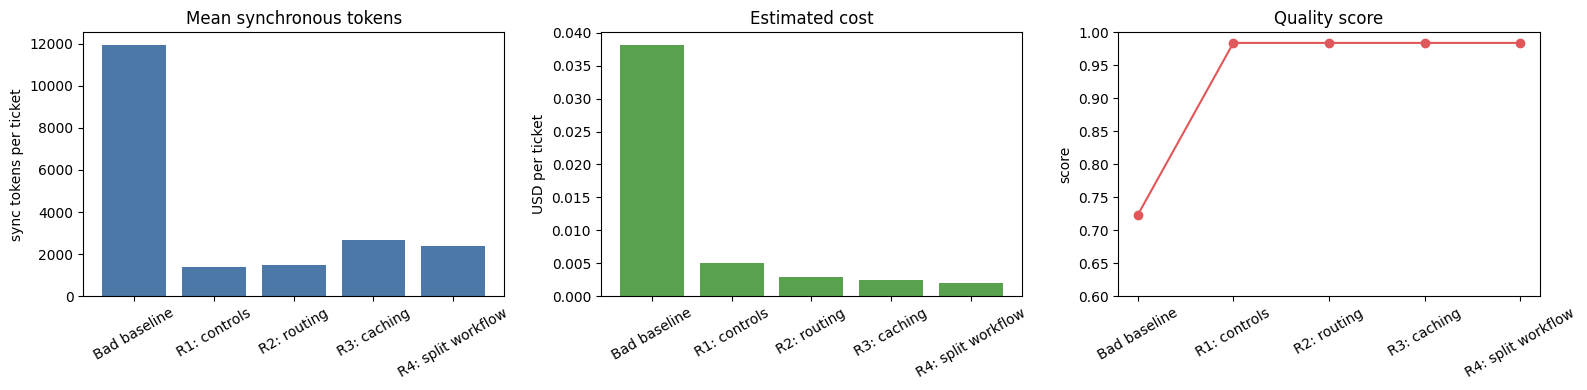

In [10]:
plot_df = summary.copy()
labels = plot_df["variant_label"].str.replace("Round ", "R", regex=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(labels, plot_df["mean_sync_tokens"], color="#4C78A8")
axes[0].set_title("Mean synchronous tokens")
axes[0].set_ylabel("sync tokens per ticket")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(labels, plot_df["cost_per_ticket_usd"], color="#59A14F")
axes[1].set_title("Estimated cost")
axes[1].set_ylabel("USD per ticket")
axes[1].tick_params(axis="x", rotation=30)

axes[2].plot(labels, plot_df["mean_quality"], marker="o", color="#E15759")
axes[2].set_ylim(0.6, 1.0)
axes[2].set_title("Quality score")
axes[2].set_ylabel("score")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


## Optional: live Responses API tool loop

The dry-run harness above is deterministic. The helper below is the live shape you would use to run a single support ticket through the Responses API with function tools.

Important details:

- The function tool schema uses the Responses API shape: `{"type": "function", "name": ..., "parameters": ...}`.
- The loop appends `response.output` before function outputs so reasoning and tool-call items are passed forward.
- The application enforces a hard tool-loop limit. This is still useful even when the prompt and `tool_choice` are well controlled.
- On follow-up turns, `previous_response_id` can carry conversation state, but instructions should be supplied again when needed.

In [11]:
LOCAL_TOOL_FUNCTIONS = {
    "lookup_customer": lookup_customer,
    "lookup_order": lookup_order,
    "lookup_policy": lookup_policy,
    "create_refund_case": create_refund_case,
    "escalate_to_human": escalate_to_human,
}

def execute_local_tool(name: str, arguments: dict[str, Any], payload: str) -> dict[str, Any]:
    if name == "lookup_customer":
        return lookup_customer(arguments["customer_id"], payload=payload)
    if name == "lookup_order":
        return lookup_order(arguments["order_id"], payload=payload)
    if name == "lookup_policy":
        return lookup_policy(arguments["topic"], payload=payload)
    if name == "create_refund_case":
        return create_refund_case(arguments["order_id"], arguments["reason"])
    if name == "escalate_to_human":
        return escalate_to_human(arguments["ticket_id"], arguments["reason"])
    return {"error": f"unknown tool: {name}"}

@dataclass
class LiveAgentConfig:
    name: str
    model: str
    instructions: str
    tools: list[dict[str, Any]]
    payload: str
    reasoning_effort: str
    verbosity: str
    max_output_tokens: int
    tool_choice: str | dict[str, Any]
    prompt_cache_key: str | None = None
    prompt_cache_retention: str | None = None
    service_tier: str | None = None
    truncation: str | None = None
    context_management: list[dict[str, Any]] | None = None

BASELINE_LIVE_CONFIG = LiveAgentConfig(
    name="00_bad_baseline",
    model="gpt-5.4",
    instructions=BAD_BASELINE_PROMPT,
    tools=VERBOSE_TOOLS,
    payload="verbose",
    reasoning_effort="high",
    verbosity="high",
    max_output_tokens=1200,
    tool_choice="required",
)

def live_config_for_ticket(ticket: dict[str, Any], variant: str) -> LiveAgentConfig:
    if variant == "00_bad_baseline":
        return BASELINE_LIVE_CONFIG

    model = route_resolution_model(ticket, variant)
    allowed_tools = ticket["expected_tools"]
    reasoning_effort = "low"
    if variant in {"02_model_routing", "03_prompt_caching", "04_split_workflow"} and ticket["risk"] == "low":
        reasoning_effort = "minimal"
    elif ticket["risk"] == "high":
        reasoning_effort = "medium"

    return LiveAgentConfig(
        name=variant,
        model=model,
        instructions=CACHE_FRIENDLY_PROMPT if variant in {"03_prompt_caching", "04_split_workflow"} else CONTROLLED_PROMPT,
        tools=SLIM_TOOLS,
        payload="slim",
        reasoning_effort=reasoning_effort,
        verbosity="low",
        max_output_tokens=260 if variant == "04_split_workflow" else 350,
        tool_choice=allowed_tool_choice(allowed_tools, mode="auto"),
        prompt_cache_key=f"support_{ticket['intent']}_v1" if variant in {"03_prompt_caching", "04_split_workflow"} else None,
        prompt_cache_retention="24h" if variant in {"03_prompt_caching", "04_split_workflow"} and model == "gpt-5.4" else None,
        service_tier="default",
        truncation="auto" if variant != "00_bad_baseline" else None,
        context_management=[{"type": "compaction", "compact_threshold": 20_000}] if variant != "00_bad_baseline" else None,
    )

ROUND1_LIVE_CONFIG = live_config_for_ticket(EVAL_SET[1], "01_prompt_tool_context_controls")
ROUND2_ROUTINE_LIVE_CONFIG = live_config_for_ticket(EVAL_SET[0], "02_model_routing")
ROUND2_HIGH_RISK_LIVE_CONFIG = live_config_for_ticket(EVAL_SET[7], "02_model_routing")
ROUND3_CACHED_LIVE_CONFIG = live_config_for_ticket(EVAL_SET[0], "03_prompt_caching")
ROUND4_SYNC_LIVE_CONFIG = live_config_for_ticket(EVAL_SET[1], "04_split_workflow")

def background_followup_request(ticket: dict[str, Any]) -> dict[str, Any]:
    return {
        "model": "gpt-5.4-nano",
        "input": json.dumps({"ticket": ticket, "policy": POLICIES[ticket["expected_policy"]]}),
        "reasoning": {"effort": "minimal"},
        "text": {"verbosity": "low"},
        "max_output_tokens": 160,
        "service_tier": "flex",
    }

def run_live_support_ticket(ticket: dict[str, Any], config: LiveAgentConfig, max_tool_rounds: int = 3) -> dict[str, Any]:
    if not RUN_LIVE_API_CALLS:
        raise RuntimeError("Set OPENAI_API_KEY and RUN_LIVE_API_CALLS=true to call the API.")

    input_items: list[Any] = [
        {
            "role": "user",
            "content": json.dumps(
                {
                    "ticket_id": ticket["ticket_id"],
                    "customer_id": ticket["customer_id"],
                    "message": ticket["message"],
                    "known_order_id": ticket.get("order_id"),
                    "expected_policy": ticket["expected_policy"],
                }
            ),
        }
    ]

    request: dict[str, Any] = {
        "model": config.model,
        "instructions": config.instructions,
        "tools": config.tools,
        "input": input_items,
        "reasoning": {"effort": config.reasoning_effort},
        "text": {"verbosity": config.verbosity},
        "max_output_tokens": config.max_output_tokens,
        "parallel_tool_calls": True,
        "tool_choice": config.tool_choice,
    }
    if config.prompt_cache_key:
        request["prompt_cache_key"] = config.prompt_cache_key
    if config.prompt_cache_retention:
        request["prompt_cache_retention"] = config.prompt_cache_retention
    if config.service_tier:
        request["service_tier"] = config.service_tier
    if config.truncation:
        request["truncation"] = config.truncation
    if config.context_management:
        request["context_management"] = config.context_management

    started = time.perf_counter()
    response = client.responses.create(**request)
    total_usage = response_usage_dict(response)
    tool_calls = 0

    for _ in range(max_tool_rounds):
        function_calls = [item for item in response.output if getattr(item, "type", None) == "function_call"]
        if not function_calls:
            break

        input_items += response.output
        for item in function_calls:
            args = json.loads(item.arguments or "{}")
            tool_result = execute_local_tool(item.name, args, config.payload)
            tool_calls += 1
            input_items.append(
                {
                    "type": "function_call_output",
                    "call_id": item.call_id,
                    "output": json.dumps(tool_result),
                }
            )

        followup_request = dict(request)
        followup_request["input"] = input_items
        followup_request["tool_choice"] = "none"
        response = client.responses.create(**followup_request)
        usage = response_usage_dict(response)
        for key in total_usage:
            total_usage[key] += usage[key]

    latency_s = time.perf_counter() - started
    cost_usd = estimate_cost_usd(
        config.model,
        total_usage["input_tokens"],
        total_usage["output_tokens"],
        total_usage["cached_tokens"],
    )

    return {
        "config": config.name,
        "ticket_id": ticket["ticket_id"],
        "model": config.model,
        "response_text": response.output_text,
        "tool_calls": tool_calls,
        "latency_s": latency_s,
        "estimated_cost_usd": cost_usd,
        **total_usage,
    }


In [12]:
if RUN_LIVE_API_CALLS:
    live_result = run_live_support_ticket(EVAL_SET[0], ROUND1_LIVE_CONFIG)
    print(live_result["response_text"])
    display(pd.DataFrame([{k: v for k, v in live_result.items() if k != "response_text"}]))
else:
    print("Dry-run mode. Set OPENAI_API_KEY and RUN_LIVE_API_CALLS=true to run a live Responses API ticket.")

Dry-run mode. Set OPENAI_API_KEY and RUN_LIVE_API_CALLS=true to run a live Responses API ticket.


## Optimization round 1: prompt, tool, and context controls

The first round removes the cheapest sources of waste:

- replace vague instructions such as "be extremely thorough" with concrete response and tool rules
- set `text.verbosity="low"` for short customer answers
- set `max_output_tokens` to cap visible and reasoning output
- reduce reasoning effort on routine tickets
- restrict callable tools with `tool_choice.allowed_tools`
- keep application-level tool-loop limits
- return minimal tool payloads
- use `truncation="auto"` or context compaction for long conversations where appropriate

In this demo, the application already knows the ticket path from mock metadata and uses that path to restrict tools. In production, validate the router separately and keep a fallback path for low-confidence routing.

Prompt optimizer or metaprompting can help here, but use it surgically: ask for a minimal patch for a specific failure mode rather than a broad rewrite.


In [13]:
round1_request_example = {
    "model": "gpt-5.4",
    "instructions": CONTROLLED_PROMPT,
    "tools": SLIM_TOOLS,
    "tool_choice": allowed_tool_choice(["lookup_order", "lookup_policy"], mode="auto"),
    "reasoning": {"effort": "low"},
    "text": {"verbosity": "low"},
    "max_output_tokens": 350,
    "parallel_tool_calls": True,
    "truncation": "auto",
    "context_management": [{"type": "compaction", "compact_threshold": 20_000}],
    "input": [
        {
            "role": "user",
            "content": "My blender arrived cracked. Order O-1002. Can you replace it?",
        }
    ],
}

print(json.dumps(round1_request_example, indent=2)[:2400] + "\n...")

{
  "model": "gpt-5.4",
  "instructions": "Role: E-commerce support assistant.\n\nGoal: Resolve routine support tickets with the fewest necessary tool calls while preserving policy correctness.\n\nTool rules:\n- Use only tools required for the current decision.\n- Order status: order lookup only.\n- Damaged delivery or refund: order lookup plus the relevant policy.\n- Billing duplicate charge: order lookup plus billing policy, then escalate.\n- Account access with unverified identity: customer lookup plus account policy, then escalate.\n\nResponse rules:\n- Give the customer the outcome and next step.\n- Do not expose internal reasoning, raw tool data, audit notes, or policy text.\n- Keep the customer-facing answer under 120 words unless escalation legally requires more detail.",
  "tools": [
    {
      "type": "function",
      "name": "lookup_customer",
      "description": "Fetch minimal customer verification and support tier fields.",
      "parameters": {
        "type": "object"

In [14]:
round1_detail = traces[traces["variant"].isin(["00_bad_baseline", "01_prompt_tool_context_controls"])]
display(
    round1_detail[
        [
            "variant_label",
            "ticket_id",
            "intent",
            "tools",
            "action",
            "extra_tool_calls",
            "policy_compliant",
            "concise",
            "visible_output_tokens",
            "total_tokens",
            "latency_s",
            "cost_usd",
            "quality_score",
        ]
    ].style.format({"cost_usd": "${:.5f}", "quality_score": "{:.2f}", "latency_s": "{:.2f}"})
)


,variant_label,ticket_id,intent,tools,action,extra_tool_calls,policy_compliant,concise,visible_output_tokens,total_tokens,latency_s,cost_usd,quality_score
0,Bad baseline,T-001,order_status,"lookup_customer, lookup_order, lookup_policy, create_refund_case, escalate_to_human",provide_status_eta,4,True,False,167,12913,4.88,$0.03993,0.80
1,Bad baseline,T-002,damaged_delivery,"lookup_customer, lookup_order, lookup_policy, create_refund_case, escalate_to_human",open_replacement_without_photo,3,False,False,174,12917,4.88,$0.04034,0.65
2,Bad baseline,T-003,refund_eligibility,"lookup_customer, lookup_order, lookup_policy, create_refund_case, escalate_to_human",escalate_refund_review,2,False,False,170,12818,4.87,$0.04004,0.50
3,Bad baseline,T-004,billing_issue,"lookup_customer, lookup_order, lookup_policy, create_refund_case, escalate_to_human",escalate_billing_review,2,True,False,169,12830,4.87,$0.04038,0.85
4,Bad baseline,T-005,account_access,"lookup_customer, lookup_order, lookup_policy, create_refund_case, escalate_to_human",escalate_account_security,2,True,False,172,8112,3.97,$0.02899,0.87
5,Bad baseline,T-006,refund_dispute,"lookup_customer, lookup_order, lookup_policy, create_refund_case, escalate_to_human",escalate_refund_review,2,True,False,168,12869,4.88,$0.04077,0.87
6,Bad baseline,T-007,delivered_not_received,"lookup_customer, lookup_order, lookup_policy, create_refund_case, escalate_to_human",start_delivery_trace_steps,3,True,False,172,12862,4.87,$0.04018,0.82
7,Bad baseline,T-008,high_value_damage,"lookup_customer, lookup_order, lookup_policy, create_refund_case, escalate_to_human",promise_refund_high_value_damage,2,False,False,174,12997,4.91,$0.04136,0.50
8,Bad baseline,T-009,refund_eligibility,"lookup_customer, lookup_order, lookup_policy, create_refund_case, escalate_to_human",escalate_refund_review,2,False,False,169,12921,4.88,$0.04029,0.50
9,Bad baseline,T-010,account_access,"lookup_customer, lookup_order, lookup_policy, create_refund_case, escalate_to_human",escalate_account_security,2,True,False,172,8115,3.97,$0.02900,0.87


## Optimization round 2: model selection

Right-size the model to each step instead of choosing one global model. Establish a GPT-5.4 baseline for each workload, and evaluate it against the same labeled tickets, prompts, tools, structured-output schema, and quality criteria.

- **Intent classification, extraction, and low-risk routing:** Use `gpt-5.4-nano` for ticket classification, entity extraction, and simple tags. Compare intent accuracy, high-risk false negatives, structured-output reliability, latency, and cost per correctly classified ticket. ([GPT-5.4 nano](https://developers.openai.com/api/docs/models/gpt-5.4-nano))

- **Routine support and order workflows:** Use `gpt-5.4-mini` for order status, damaged delivery, straightforward refund-eligibility checks, and other repeatable support tasks that require policy interpretation or tool use. Evaluate resolution correctness, tool-call accuracy, policy compliance, p50/p95 latency, and cost per successfully resolved ticket. ([GPT-5.4 mini](https://developers.openai.com/api/docs/models/gpt-5.4-mini))

- **Complex or high-risk cases:** Use `gpt-5.4` for account-access problems, duplicate-charge escalations, refund disputes, and other high-consequence interactions. Preserve deterministic authorization and refund checks, explicit escalation rules, and human review where required. Measure resolution quality, policy adherence, latency, and end-to-end cost. ([GPT-5.4](https://developers.openai.com/api/docs/models/gpt-5.4))

The GPT-5.6 family offers newer models that correspond to these same tiers. [GPT-5.6 Luna](https://developers.openai.com/api/docs/models/gpt-5.6-luna) (`gpt-5.6-luna`) maps to the nano tier for classification and high-volume tasks. [GPT-5.6 Terra](https://developers.openai.com/api/docs/models/gpt-5.6-terra) (`gpt-5.6-terra`) maps to the mini tier for routine support workflows. [GPT-5.6 Sol](https://developers.openai.com/api/docs/models/gpt-5.6-sol) (`gpt-5.6-sol`) maps to the full-model tier for complex or high-risk cases. Each can be evaluated against its corresponding GPT-5.4 baseline using the same tickets and quality criteria.

For each comparison, begin with the existing reasoning-effort setting and also evaluate one level lower. A newer model can be more economical at the task level if it resolves tickets with fewer retries, unnecessary tool calls, or escalations. Consider fine-tuning only if a selected model explicitly supports it. ([GPT-5.6 migration guidance](https://developers.openai.com/api/docs/guides/latest-model))


In [15]:
TRIAGE_SCHEMA = {
    "type": "json_schema",
    "name": "support_triage",
    "strict": True,
    "schema": {
        "type": "object",
        "properties": {
            "intent": {
                "type": "string",
                "enum": [
                    "order_status",
                    "damaged_delivery",
                    "refund_eligibility",
                    "billing_issue",
                    "account_access",
                    "refund_dispute",
                    "delivered_not_received",
                    "high_value_damage",
                ],
            },
            "risk": {"type": "string", "enum": ["low", "medium", "high"]},
            "needs_human": {"type": "boolean"},
            "order_id": {"type": ["string", "null"]},
        },
        "required": ["intent", "risk", "needs_human", "order_id"],
        "additionalProperties": False,
    },
}

def live_triage_example(customer_message: str) -> dict[str, Any] | None:
    if not RUN_LIVE_API_CALLS:
        return None
    response = client.responses.create(
        model="gpt-5.4-nano",
        instructions="Classify an e-commerce support ticket. Return only the structured object.",
        input=customer_message,
        reasoning={"effort": "minimal"},
        text={"format": TRIAGE_SCHEMA, "verbosity": "low"},
        max_output_tokens=120,
    )
    return json.loads(response.output_text)

print("Example triage schema:")
print(json.dumps(TRIAGE_SCHEMA, indent=2)[:1800] + "\n...")


Example triage schema:
{
  "type": "json_schema",
  "name": "support_triage",
  "strict": true,
  "schema": {
    "type": "object",
    "properties": {
      "intent": {
        "type": "string",
        "enum": [
          "order_status",
          "damaged_delivery",
          "refund_eligibility",
          "billing_issue",
          "account_access",
          "refund_dispute",
          "delivered_not_received",
          "high_value_damage"
        ]
      },
      "risk": {
        "type": "string",
        "enum": [
          "low",
          "medium",
          "high"
        ]
      },
      "needs_human": {
        "type": "boolean"
      },
      "order_id": {
        "type": [
          "string",
          "null"
        ]
      }
    },
    "required": [
      "intent",
      "risk",
      "needs_human",
      "order_id"
    ],
    "additionalProperties": false
  }
}
...


In [16]:
model_routing_view = traces[traces["variant"].isin(["01_prompt_tool_context_controls", "02_model_routing"])]
display(
    model_routing_view[
        [
            "variant_label",
            "ticket_id",
            "intent",
            "risk",
            "model",
            "routing_tokens",
            "total_tokens",
            "sync_cost_usd",
            "quality_score",
            "policy_compliant",
        ]
    ].style.format({"sync_cost_usd": "${:.5f}", "quality_score": "{:.2f}"})
)


,variant_label,ticket_id,intent,risk,model,routing_tokens,total_tokens,sync_cost_usd,quality_score,policy_compliant
10,Round 1: controls,T-001,order_status,low,gpt-5.4,0,1252,$0.00418,0.98,True
11,Round 1: controls,T-002,damaged_delivery,medium,gpt-5.4,0,1354,$0.00482,0.98,True
12,Round 1: controls,T-003,refund_eligibility,medium,gpt-5.4,0,1389,$0.00506,0.98,True
13,Round 1: controls,T-004,billing_issue,medium,gpt-5.4,0,1383,$0.00512,0.98,True
14,Round 1: controls,T-005,account_access,high,gpt-5.4,0,1374,$0.00537,0.99,True
15,Round 1: controls,T-006,refund_dispute,high,gpt-5.4,0,1418,$0.00545,0.99,True
16,Round 1: controls,T-007,delivered_not_received,medium,gpt-5.4,0,1390,$0.00486,0.98,True
17,Round 1: controls,T-008,high_value_damage,high,gpt-5.4,0,1445,$0.00568,0.99,True
18,Round 1: controls,T-009,refund_eligibility,low,gpt-5.4,0,1393,$0.00507,0.98,True
19,Round 1: controls,T-010,account_access,high,gpt-5.4,0,1378,$0.00538,0.99,True


## Optimization round 3: prompt caching

Every support request includes the same core instructions, policy rules, tool definitions, and response schema. Prompt caching lets the API reuse that shared context across tickets, reducing repeated processing and lowering input-token costs. Customer-specific details, such as order IDs, account information, and retrieved records, should appear after the shared prefix.

Prompt caching has evolved between model generations. With `gpt-5.4-mini`, the API automatically identifies repeated prefixes and can reuse the shared support context even when the customer-specific details change. Writing a new prefix does not add a separate cache-write charge. Keep the tool definitions consistent and use `tool_choice.allowed_tools` to control which tools are available without changing the shared tool list.

GPT-5.6 introduces two changes: cache writes are billed, and developers can explicitly choose which part of the prompt should be cached. With `gpt-5.6-luna`, `gpt-5.6-terra`, or `gpt-5.6-sol`, the default cache breakpoint is placed after the latest message. If that message contains a different customer question or order ID each time, otherwise similar tickets may not reuse the shared support context. Because writing content to cache costs 1.25 times the normal input-token price, repeatedly caching those unique messages can increase cost without creating useful reuse.

For example, two order-status tickets can share the same support instructions, policy rules, and tools, even though one asks about order `O-1001` and the other asks about order `O-2002`. Place an explicit cache breakpoint after the shared support playbook and before the order-specific details. Set `prompt_cache_options` to explicit mode with `ttl="30m"`, and use the same `prompt_cache_key`, such as `support_order_status_v1`, for both requests. The first ticket writes the shared playbook once, and later tickets reuse it at a 90% discount while processing their own order details normally.

Compare `cached_tokens` and `cache_write_tokens` alongside latency and cost per resolved ticket. For additional implementation details, see the [prompt caching guide](https://developers.openai.com/api/docs/guides/prompt-caching).


In [17]:
cache_friendly_request = {
    "model": "gpt-5.4-mini",
    "instructions": CACHE_FRIENDLY_PROMPT,
    "tools": SLIM_TOOLS,
    "tool_choice": allowed_tool_choice(["lookup_order"], mode="auto"),
    "prompt_cache_key": "support_order_status_v1",
    "reasoning": {"effort": "low"},
    "text": {"verbosity": "low"},
    "max_output_tokens": 300,
    "input": [
        {
            "role": "user",
            "content": json.dumps(
                {
                    "ticket_id": "T-001",
                    "customer_id": "C-100",
                    "message": "Where is order O-1001?",
                    "order_id": "O-1001",
                }
            ),
        }
    ],
}

print(json.dumps(cache_friendly_request, indent=2)[:2400] + "\n...")


{
  "model": "gpt-5.4-mini",
  "instructions": "Role: E-commerce support assistant.\nConstraints: Be concise, policy-compliant, and explicit about next steps. Do not disclose internal data.\nEscalate: duplicate charges, account access without verification, high-value disputes, and refunds outside the window.\nOutput shape: customer_message, resolution_type, escalate, internal_tags.\nTool contract: tool definitions are stable across requests; restrict callable tools with tool_choice.allowed_tools.\nVersion: support-agent-optimization-v1.\n\nStable support playbook digest:\n- Shipping delays: provide status, ETA, and tracking next steps; do not refund solely for short carrier delays.\n- Delivered-not-received: verify delivery details, ask the customer to check common locations, and start carrier trace steps when appropriate.\n- Damaged delivery: request photo evidence before offering replacement or refund; high-value damaged items require human review.\n- Refunds: standard returnable ite

In [18]:
previous_response_id_example = '''
first = client.responses.create(
    model="gpt-5.4-mini",
    instructions=STABLE_SUPPORT_PREFIX,
    tools=SLIM_TOOLS,
    input="Customer asks: Where is order O-1001?",
    prompt_cache_key="support_order_status_v1",
)

follow_up = client.responses.create(
    model="gpt-5.4-mini",
    previous_response_id=first.id,
    instructions=STABLE_SUPPORT_PREFIX,
    input="Customer follow-up: the carrier link is stale. What should I do?",
    prompt_cache_key="support_order_status_v1",
)
'''

print(previous_response_id_example)


first = client.responses.create(
    model="gpt-5.4-mini",
    instructions=STABLE_SUPPORT_PREFIX,
    tools=SLIM_TOOLS,
    input="Customer asks: Where is order O-1001?",
    prompt_cache_key="support_order_status_v1",
)

follow_up = client.responses.create(
    model="gpt-5.4-mini",
    previous_response_id=first.id,
    instructions=STABLE_SUPPORT_PREFIX,
    input="Customer follow-up: the carrier link is stale. What should I do?",
    prompt_cache_key="support_order_status_v1",
)



In [19]:
caching_view = traces[traces["variant"].isin(["02_model_routing", "03_prompt_caching"])]
display(
    caching_view[
        [
            "variant_label",
            "ticket_id",
            "model",
            "input_tokens",
            "cacheable_prefix_tokens",
            "cached_tokens",
            "latency_input_tokens",
            "output_tokens",
            "cost_usd",
            "latency_s",
            "quality_score",
        ]
    ].style.format({"cost_usd": "${:.5f}", "quality_score": "{:.2f}", "latency_s": "{:.2f}"})
)


,variant_label,ticket_id,model,input_tokens,cacheable_prefix_tokens,cached_tokens,latency_input_tokens,output_tokens,cost_usd,latency_s,quality_score
20,Round 2: routing,T-001,gpt-5.4-mini,1068,0,0,1068,77,$0.00123,1.56,0.98
21,Round 2: routing,T-002,gpt-5.4-mini,1139,0,0,1139,104,$0.00141,1.72,0.98
22,Round 2: routing,T-003,gpt-5.4-mini,1162,0,0,1162,114,$0.00147,1.87,0.98
23,Round 2: routing,T-004,gpt-5.4-mini,1150,0,0,1150,117,$0.00147,1.87,0.98
24,Round 2: routing,T-005,gpt-5.4,1119,0,0,1119,161,$0.00530,2.48,0.99
25,Round 2: routing,T-006,gpt-5.4,1166,0,0,1166,158,$0.00537,2.49,0.99
26,Round 2: routing,T-007,gpt-5.4-mini,1179,0,0,1179,100,$0.00142,1.73,0.98
27,Round 2: routing,T-008,gpt-5.4,1180,0,0,1180,172,$0.00562,2.49,0.99
28,Round 2: routing,T-009,gpt-5.4-mini,1166,0,0,1166,114,$0.00147,1.87,0.98
29,Round 2: routing,T-010,gpt-5.4,1123,0,0,1123,161,$0.00531,2.48,0.99


## Optimization round 4: split the workflow

Keep only customer-facing resolution work in the synchronous path:

- understand the request
- retrieve the needed order or policy context
- make the resolution or escalation decision
- draft the customer response

Move these to follow-up work unless they change the immediate customer outcome:

- post-resolution QA
- analytics tagging
- internal summaries
- routing audits
- knowledge-gap mining
- nightly reporting

For infrastructure:

- use default or priority processing for user-facing requests depending on latency needs
- use `service_tier="flex"` for lower-priority normal request-path work that can tolerate slower processing
- use Batch API for asynchronous work with a `24h` completion window

In [20]:
sync_request = {
    "model": "gpt-5.4-mini",
    "instructions": CACHE_FRIENDLY_PROMPT,
    "tools": SLIM_TOOLS,
    "tool_choice": allowed_tool_choice(["lookup_order", "lookup_policy"], mode="auto"),
    "input": "Customer says order O-1002 arrived cracked. Resolve or escalate.",
    "reasoning": {"effort": "low"},
    "text": {"verbosity": "low"},
    "max_output_tokens": 260,
    "service_tier": "default",
    "prompt_cache_key": "support_damaged_delivery_v1",
}

background_flex_request = background_followup_request(EVAL_SET[1])

print("Synchronous customer-facing request:")
print(json.dumps(sync_request, indent=2)[:1800] + "\n...")
print("\nFollow-up flex request:")
print(json.dumps(background_flex_request, indent=2)[:1600] + "\n...")


Synchronous customer-facing request:
{
  "model": "gpt-5.4-mini",
  "instructions": "Role: E-commerce support assistant.\nConstraints: Be concise, policy-compliant, and explicit about next steps. Do not disclose internal data.\nEscalate: duplicate charges, account access without verification, high-value disputes, and refunds outside the window.\nOutput shape: customer_message, resolution_type, escalate, internal_tags.\nTool contract: tool definitions are stable across requests; restrict callable tools with tool_choice.allowed_tools.\nVersion: support-agent-optimization-v1.\n\nStable support playbook digest:\n- Shipping delays: provide status, ETA, and tracking next steps; do not refund solely for short carrier delays.\n- Delivered-not-received: verify delivery details, ask the customer to check common locations, and start carrier trace steps when appropriate.\n- Damaged delivery: request photo evidence before offering replacement or refund; high-value damaged items require human review

In [21]:
batch_requests = []
for ticket in EVAL_SET:
    batch_requests.append(
        {
            "custom_id": f"qa-{ticket['ticket_id']}",
            "method": "POST",
            "url": "/v1/responses",
            "body": {
                "model": "gpt-5.4-nano",
                "instructions": "Return concise internal support QA tags and a one-sentence summary.",
                "input": json.dumps(ticket),
                "reasoning": {"effort": "minimal"},
                "text": {"verbosity": "low"},
                "max_output_tokens": 160,
            },
        }
    )

batch_file_path = "nightly_support_qa_batch.jsonl"
with open(batch_file_path, "w") as f:
    for row in batch_requests:
        f.write(json.dumps(row) + "\n")

print(f"Wrote {len(batch_requests)} example batch rows to {batch_file_path}")
print(json.dumps(batch_requests[0], indent=2))

Wrote 10 example batch rows to nightly_support_qa_batch.jsonl
{
  "custom_id": "qa-T-001",
  "method": "POST",
  "url": "/v1/responses",
  "body": {
    "model": "gpt-5.4-nano",
    "instructions": "Return concise internal support QA tags and a one-sentence summary.",
    "input": "{\"ticket_id\": \"T-001\", \"customer_id\": \"C-100\", \"message\": \"Where is order O-1001? It was supposed to arrive yesterday.\", \"intent\": \"order_status\", \"order_id\": \"O-1001\", \"risk\": \"low\", \"difficulty\": \"simple_lookup\", \"must_escalate\": false, \"expected_policy\": \"shipping\", \"expected_tools\": [\"lookup_order\"], \"expected_action\": \"provide_status_eta\", \"expected_resolution_type\": \"resolved\", \"expected_customer_response_contains\": [\"in transit\", \"tomorrow\"], \"forbidden_response_claims\": [\"refund completed\", \"replacement opened\"]}",
    "reasoning": {
      "effort": "minimal"
    },
    "text": {
      "verbosity": "low"
    },
    "max_output_tokens": 160
  }

In [22]:
batch_submission_example = '''
batch_input_file = client.files.create(
    file=open("nightly_support_qa_batch.jsonl", "rb"),
    purpose="batch",
)

batch = client.batches.create(
    input_file_id=batch_input_file.id,
    endpoint="/v1/responses",
    completion_window="24h",
    metadata={"description": "nightly support QA tags"},
)
'''

print(batch_submission_example)


batch_input_file = client.files.create(
    file=open("nightly_support_qa_batch.jsonl", "rb"),
    purpose="batch",
)

batch = client.batches.create(
    input_file_id=batch_input_file.id,
    endpoint="/v1/responses",
    completion_window="24h",
    metadata={"description": "nightly support QA tags"},
)



In [23]:
split_view = traces[traces["variant"].isin(["03_prompt_caching", "04_split_workflow"])]
display(
    split_view[
        [
            "variant_label",
            "ticket_id",
            "model",
            "tool_calls",
            "sync_tokens",
            "total_tokens",
            "background_tokens",
            "latency_s",
            "sync_cost_usd",
            "background_cost_usd",
            "cost_usd",
            "quality_score",
        ]
    ].style.format(
        {
            "sync_cost_usd": "${:.5f}",
            "background_cost_usd": "${:.5f}",
            "cost_usd": "${:.5f}",
            "quality_score": "{:.2f}",
            "latency_s": "{:.2f}",
        }
    )
)


,variant_label,ticket_id,model,tool_calls,sync_tokens,total_tokens,background_tokens,latency_s,sync_cost_usd,background_cost_usd,cost_usd,quality_score
30,Round 3: caching,T-001,gpt-5.4-mini,1,2552,2552,0,1.54,$0.00094,$0.00000,$0.00094,0.98
31,Round 3: caching,T-002,gpt-5.4-mini,2,2650,2650,0,1.70,$0.00112,$0.00000,$0.00112,0.98
32,Round 3: caching,T-003,gpt-5.4-mini,3,2685,2685,0,1.85,$0.00118,$0.00000,$0.00118,0.98
33,Round 3: caching,T-004,gpt-5.4-mini,3,2673,2673,0,1.84,$0.00118,$0.00000,$0.00118,0.98
34,Round 3: caching,T-005,gpt-5.4,3,2685,2685,0,2.45,$0.00429,$0.00000,$0.00429,0.99
35,Round 3: caching,T-006,gpt-5.4,3,2735,2735,0,2.46,$0.00437,$0.00000,$0.00437,0.99
36,Round 3: caching,T-007,gpt-5.4-mini,2,2691,2691,0,1.70,$0.00113,$0.00000,$0.00113,0.98
37,Round 3: caching,T-008,gpt-5.4,3,2769,2769,0,2.47,$0.00461,$0.00000,$0.00461,0.99
38,Round 3: caching,T-009,gpt-5.4-mini,3,2693,2693,0,1.85,$0.00118,$0.00000,$0.00118,0.98
39,Round 3: caching,T-010,gpt-5.4,3,2692,2692,0,2.45,$0.00430,$0.00000,$0.00430,0.99


## Tradeoffs and scenario mapping

There is no universal best configuration. The sweet spot depends on traffic shape, customer promise, policy risk, cache hit rate, tool latency, observability maturity, and how much work can move out of the synchronous path.

The important tradeoffs for support agents are:

| Constraint | Pushes you toward | Watch out for |
|---|---|---|
| High policy or account-security risk | Larger model on high-risk paths, stricter escalation, judge evals | Over-escalation can hurt customer experience and support capacity |
| High ticket volume with repeated workflows | Stable prefixes, prompt caching, smaller models, Batch for follow-up work | Cache misses on large prefixes can add latency |
| Low latency customer promise | Short prompts, slim tool payloads, routing, async follow-up work | Too much routing can add overhead if the task is already simple |
| Strict cost target | Nano/mini for triage and routine paths, output caps, flex or Batch for offline work | Cost-only tuning can remove safeguards if quality gates are weak |
| Messy tools or unreliable data | Fewer tool calls, validated payloads, fallbacks, escalation on tool failure | Blindly shrinking context can remove the evidence needed for policy decisions |
| Premium or regulated support | Higher quality floor, lower escalation threshold, more audit metadata offline | More synchronous review increases latency and cost |
| Seasonal bursts | Cache-friendly requests, queue-aware service tiers, async analytics | Peak traffic can reduce cache effectiveness if routing keys are too fragmented |

The table below maps common operating scenarios to candidate configurations. Treat this as a design aid: choose the cheapest configuration that clears the quality, latency, and operational constraints for that scenario.


### Candidate architecture combinations

This table compares candidate agent architectures for the same customer-support use case. It uses the notebook's mock eval set and deterministic dry-run simulation metrics, not live API traces. Use the relative differences to understand tradeoffs; replace these metrics with production trace data before making deployment decisions.


In [24]:
ARCHITECTURE_OPTIONS = {
    "baseline_one_big_agent": {
        "label": "One broad agent",
        "variant": "00_bad_baseline",
        "models": "gpt-5.4 for every step",
        "tools": "all tools exposed",
        "cache": "none",
        "workflow": "all work synchronous",
        "best_for": "prototype smell test only",
    },
    "controlled_full_model": {
        "label": "Controlled full model",
        "variant": "01_prompt_tool_context_controls",
        "models": "gpt-5.4 for resolution",
        "tools": "allowed tools by routed path",
        "cache": "none",
        "workflow": "some follow-up still synchronous",
        "best_for": "high-risk launch or low confidence in routing/model mix",
    },
    "routed_no_cache": {
        "label": "Routed, no cache",
        "variant": "02_model_routing",
        "models": "nano triage, mini routine, gpt-5.4 high risk",
        "tools": "allowed tools by routed path",
        "cache": "none",
        "workflow": "some follow-up still synchronous",
        "best_for": "mixed ticket queues with moderate repeat traffic",
    },
    "routed_split_no_cache": {
        "label": "Routed split, no cache",
        "variant": None,
        "models": "nano triage/tags, mini routine, gpt-5.4 high risk",
        "tools": "allowed tools by routed path",
        "cache": "none",
        "workflow": "customer path sync, QA/tags/reporting async",
        "best_for": "low-repeat queues that still need async follow-up work",
    },
    "routed_cache": {
        "label": "Routed + cache",
        "variant": "03_prompt_caching",
        "models": "nano triage, mini routine, gpt-5.4 high risk",
        "tools": "stable full tool list plus allowed_tools",
        "cache": "stable playbook prefix",
        "workflow": "some follow-up still synchronous",
        "best_for": "high-volume repeated workflows with good cache locality",
    },
    "balanced_split": {
        "label": "Balanced split workflow",
        "variant": "04_split_workflow",
        "models": "nano triage/tags, mini routine, gpt-5.4 high risk",
        "tools": "stable full tool list plus allowed_tools",
        "cache": "stable playbook prefix",
        "workflow": "customer path sync, QA/tags/reporting async",
        "best_for": "most mature repeated-workflow support deployments",
    },
}

def architecture_metrics(option_key: str) -> dict[str, Any]:
    option = ARCHITECTURE_OPTIONS[option_key]
    if option["variant"] is not None:
        row = summary.loc[summary["variant"] == option["variant"]].iloc[0].to_dict()
        return {
            "quality": row["mean_quality"],
            "policy_compliance": row["policy_compliance"],
            "p50_latency_s": row["p50_latency_s"],
            "cost_per_ticket_usd": row["cost_per_ticket_usd"],
            "monthly_cost_at_100k_tickets": row["monthly_cost_at_100k_tickets"],
        }

    # Custom combination: use the routed model/tool strategy, remove sync follow-up work,
    # but do not add the larger cache-friendly prefix. This is useful when cache locality is low.
    routed = summary.loc[summary["variant"] == "02_model_routing"].iloc[0].to_dict()
    split = summary.loc[summary["variant"] == "04_split_workflow"].iloc[0].to_dict()
    cost_per_ticket = max(routed["cost_per_ticket_usd"] - 0.00028, 0) + split["background_cost_per_ticket_usd"]
    return {
        "quality": routed["mean_quality"],
        "policy_compliance": routed["policy_compliance"],
        "p50_latency_s": max(routed["p50_latency_s"] - 0.30, 0.5),
        "cost_per_ticket_usd": cost_per_ticket,
        "monthly_cost_at_100k_tickets": cost_per_ticket * 100_000,
    }

OPERATING_SCENARIOS = [
    {
        "scenario": "Early pilot",
        "description": "Low volume, quality learning matters more than unit cost.",
        "quality_floor": 0.94,
        "policy_floor": 0.98,
        "p50_latency_target_s": 3.0,
        "monthly_budget_100k_usd": 800,
        "needs_async": False,
        "cache_locality": "low",
        "recommended": ["controlled_full_model", "routed_no_cache"],
    },
    {
        "scenario": "High-volume routine ecommerce",
        "description": "Many repeated order, return, and damage workflows.",
        "quality_floor": 0.96,
        "policy_floor": 0.99,
        "p50_latency_target_s": 2.0,
        "monthly_budget_100k_usd": 300,
        "needs_async": True,
        "cache_locality": "high",
        "recommended": ["balanced_split", "routed_cache"],
    },
    {
        "scenario": "Premium support",
        "description": "Higher customer value, lower tolerance for wrong actions.",
        "quality_floor": 0.98,
        "policy_floor": 1.0,
        "p50_latency_target_s": 2.5,
        "monthly_budget_100k_usd": 650,
        "needs_async": True,
        "cache_locality": "medium",
        "recommended": ["balanced_split", "routed_split_no_cache", "controlled_full_model"],
    },
    {
        "scenario": "Peak sale burst",
        "description": "Latency and cost matter during temporary traffic spikes.",
        "quality_floor": 0.95,
        "policy_floor": 0.99,
        "p50_latency_target_s": 1.8,
        "monthly_budget_100k_usd": 250,
        "needs_async": True,
        "cache_locality": "high",
        "recommended": ["balanced_split"],
    },
    {
        "scenario": "Low-repeat long tail",
        "description": "Many rare ticket types; cache hit rate is uncertain.",
        "quality_floor": 0.96,
        "policy_floor": 0.99,
        "p50_latency_target_s": 2.5,
        "monthly_budget_100k_usd": 450,
        "needs_async": True,
        "cache_locality": "low",
        "recommended": ["routed_split_no_cache", "routed_no_cache"],
    },
    {
        "scenario": "Account and billing sensitive queue",
        "description": "Risky account recovery and duplicate-charge workflows dominate.",
        "quality_floor": 0.98,
        "policy_floor": 1.0,
        "p50_latency_target_s": 2.8,
        "monthly_budget_100k_usd": 750,
        "needs_async": True,
        "cache_locality": "medium",
        "recommended": ["balanced_split", "routed_split_no_cache", "controlled_full_model"],
    },
]

architecture_rows = []
for key, option in ARCHITECTURE_OPTIONS.items():
    metrics = architecture_metrics(key)
    architecture_rows.append(
        {
            "architecture": key,
            "label": option["label"],
            "models": option["models"],
            "tools": option["tools"],
            "cache": option["cache"],
            "workflow": option["workflow"],
            **metrics,
            "best_for": option["best_for"],
        }
    )

architecture_df = pd.DataFrame(architecture_rows)
print("Table: Candidate architecture combinations (mock eval set + deterministic dry-run metrics)")
display(
    architecture_df[
        [
            "label",
            "models",
            "tools",
            "cache",
            "workflow",
            "quality",
            "policy_compliance",
            "p50_latency_s",
            "monthly_cost_at_100k_tickets",
            "best_for",
        ]
    ].style.format(
        {
            "quality": "{:.2f}",
            "policy_compliance": "{:.0%}",
            "p50_latency_s": "{:.2f}",
            "monthly_cost_at_100k_tickets": "${:,.0f}",
        }
    )
)


Table: Candidate architecture combinations (mock eval set + deterministic dry-run metrics)


,label,models,tools,cache,workflow,quality,policy_compliance,p50_latency_s,monthly_cost_at_100k_tickets,best_for
0,One broad agent,gpt-5.4 for every step,all tools exposed,none,all work synchronous,0.72,60%,4.88,"$3,813",prototype smell test only
1,Controlled full model,gpt-5.4 for resolution,allowed tools by routed path,none,some follow-up still synchronous,0.98,100%,2.32,$510,high-risk launch or low confidence in routing/model mix
2,"Routed, no cache","nano triage, mini routine, gpt-5.4 high risk",allowed tools by routed path,none,some follow-up still synchronous,0.98,100%,1.87,$301,mixed ticket queues with moderate repeat traffic
3,"Routed split, no cache","nano triage/tags, mini routine, gpt-5.4 high risk",allowed tools by routed path,none,"customer path sync, QA/tags/reporting async",0.98,100%,1.57,$283,low-repeat queues that still need async follow-up work
4,Routed + cache,"nano triage, mini routine, gpt-5.4 high risk",stable full tool list plus allowed_tools,stable playbook prefix,some follow-up still synchronous,0.98,100%,1.85,$243,high-volume repeated workflows with good cache locality
5,Balanced split workflow,"nano triage/tags, mini routine, gpt-5.4 high risk",stable full tool list plus allowed_tools,stable playbook prefix,"customer path sync, QA/tags/reporting async",0.98,100%,1.41,$203,most mature repeated-workflow support deployments


### Scenario sweet spots

This table maps common real-world operating scenarios to the best-scoring architecture combination. The scenario constraints are mocked for demonstration, and the architecture metrics come from the dry-run simulation above. In production, replace the constraints with your support SLAs, budget, policy-risk thresholds, and observed cache hit rates.


In [25]:
def scenario_fit_score(scenario: dict[str, Any], option_key: str) -> dict[str, Any]:
    option = ARCHITECTURE_OPTIONS[option_key]
    metrics = architecture_metrics(option_key)

    quality_ok = metrics["quality"] >= scenario["quality_floor"]
    policy_ok = metrics["policy_compliance"] >= scenario["policy_floor"]
    latency_ok = metrics["p50_latency_s"] <= scenario["p50_latency_target_s"]
    budget_ok = metrics["monthly_cost_at_100k_tickets"] <= scenario["monthly_budget_100k_usd"]
    async_ok = (not scenario["needs_async"]) or "async" in option["workflow"]

    cache_penalty = 0
    if scenario["cache_locality"] == "low" and option["cache"] != "none":
        cache_penalty = 3
    elif scenario["cache_locality"] == "medium" and option["cache"] != "none":
        cache_penalty = 1

    score = 0
    score += 3 if quality_ok else -4
    score += 3 if policy_ok else -5
    score += 2 if latency_ok else -2
    score += 2 if budget_ok else -2
    score += 2 if async_ok else -1
    score -= cache_penalty
    if option_key in scenario["recommended"]:
        score += 1

    failed_constraints = []
    if not quality_ok:
        failed_constraints.append("quality")
    if not policy_ok:
        failed_constraints.append("policy")
    if not latency_ok:
        failed_constraints.append("latency")
    if not budget_ok:
        failed_constraints.append("budget")
    if not async_ok:
        failed_constraints.append("async split")
    if cache_penalty:
        failed_constraints.append("cache locality")

    return {
        "scenario": scenario["scenario"],
        "architecture": option_key,
        "label": option["label"],
        "score": score,
        **metrics,
        "failed_constraints": ", ".join(failed_constraints) or "none",
    }

fit_rows = [
    scenario_fit_score(scenario, option_key)
    for scenario in OPERATING_SCENARIOS
    for option_key in ARCHITECTURE_OPTIONS
]
fit_df = pd.DataFrame(fit_rows)

best_fit = (
    fit_df.sort_values(["scenario", "score", "monthly_cost_at_100k_tickets"], ascending=[True, False, True])
    .groupby("scenario", sort=False)
    .head(1)
    .reset_index(drop=True)
)

scenario_context = pd.DataFrame(OPERATING_SCENARIOS)[
    [
        "scenario",
        "description",
        "quality_floor",
        "policy_floor",
        "p50_latency_target_s",
        "monthly_budget_100k_usd",
        "needs_async",
        "cache_locality",
    ]
]

best_fit_view = best_fit.merge(scenario_context, on="scenario")

print("Table: Recommended sweet spot by scenario (mock constraints + dry-run architecture metrics)")
display(
    best_fit_view[
        [
            "scenario",
            "description",
            "label",
            "score",
            "quality",
            "quality_floor",
            "policy_compliance",
            "policy_floor",
            "p50_latency_s",
            "p50_latency_target_s",
            "monthly_cost_at_100k_tickets",
            "monthly_budget_100k_usd",
            "cache_locality",
            "failed_constraints",
        ]
    ].style.format(
        {
            "quality": "{:.2f}",
            "quality_floor": "{:.2f}",
            "policy_compliance": "{:.0%}",
            "policy_floor": "{:.0%}",
            "p50_latency_s": "{:.2f}",
            "p50_latency_target_s": "{:.2f}",
            "monthly_cost_at_100k_tickets": "${:,.0f}",
            "monthly_budget_100k_usd": "${:,.0f}",
        }
    )
)


Table: Recommended sweet spot by scenario (mock constraints + dry-run architecture metrics)


,scenario,description,label,score,quality,quality_floor,policy_compliance,policy_floor,p50_latency_s,p50_latency_target_s,monthly_cost_at_100k_tickets,monthly_budget_100k_usd,cache_locality,failed_constraints
0,Account and billing sensitive queue,Risky account recovery and duplicate-charge workflows dominate.,"Routed split, no cache",13,0.98,0.98,100%,100%,1.57,2.80,$283,$750,medium,none
1,Early pilot,"Low volume, quality learning matters more than unit cost.","Routed, no cache",13,0.98,0.94,100%,98%,1.87,3.00,$301,$800,low,none
2,High-volume routine ecommerce,"Many repeated order, return, and damage workflows.",Balanced split workflow,13,0.98,0.96,100%,99%,1.41,2.00,$203,$300,high,none
3,Low-repeat long tail,Many rare ticket types; cache hit rate is uncertain.,"Routed split, no cache",13,0.98,0.96,100%,99%,1.57,2.50,$283,$450,low,none
4,Peak sale burst,Latency and cost matter during temporary traffic spikes.,Balanced split workflow,13,0.98,0.95,100%,99%,1.41,1.80,$203,$250,high,none
5,Premium support,"Higher customer value, lower tolerance for wrong actions.","Routed split, no cache",13,0.98,0.98,100%,100%,1.57,2.50,$283,$650,medium,none


### Full combination map for one scenario

This table shows all architecture options for one mocked scenario: `Low-repeat long tail`. It is included to make the tradeoff visible rather than hiding everything behind the single best pick. The numbers are still simulated; the point is to show why cache-heavy designs are less attractive when cache locality is low.


In [26]:
# Show the full combination map for one scenario so tradeoffs are visible, not hidden behind the best pick.
scenario_to_inspect = "Low-repeat long tail"
combo_map = fit_df[fit_df["scenario"] == scenario_to_inspect].sort_values("score", ascending=False)

print(f"Table: Full architecture ranking for {scenario_to_inspect} (mock scenario + dry-run metrics)")
display(
    combo_map[
        [
            "label",
            "score",
            "quality",
            "policy_compliance",
            "p50_latency_s",
            "monthly_cost_at_100k_tickets",
            "failed_constraints",
        ]
    ].style.format(
        {
            "quality": "{:.2f}",
            "policy_compliance": "{:.0%}",
            "p50_latency_s": "{:.2f}",
            "monthly_cost_at_100k_tickets": "${:,.0f}",
        }
    )
)


Table: Full architecture ranking for Low-repeat long tail (mock scenario + dry-run metrics)


,label,score,quality,policy_compliance,p50_latency_s,monthly_cost_at_100k_tickets,failed_constraints
27,"Routed split, no cache",13,0.98,100%,1.57,$283,none
26,"Routed, no cache",10,0.98,100%,1.87,$301,async split
29,Balanced split workflow,9,0.98,100%,1.41,$203,cache locality
28,Routed + cache,6,0.98,100%,1.85,$243,"async split, cache locality"
25,Controlled full model,5,0.98,100%,2.32,$510,"budget, async split"
24,One broad agent,-14,0.72,60%,4.88,"$3,813","quality, policy, latency, budget, async split"


In this mock support queue, the balanced split workflow is the sweet spot for repeated, mature support deployments because it preserves quality, keeps high-risk tickets on the stronger model, uses cache-friendly stable prefixes, and moves QA/tagging/reporting off the customer-facing path.

That is not always the right answer:

- If cache locality is low but async follow-up work is still important, the sweet spot is often routed split with no cache.
- If cache locality is low and async follow-up is not required, routed no-cache can be simpler and nearly as good.
- If the system is early in rollout and routing confidence is low, controlled full-model resolution is a safer starting point.
- If policy risk is high, do not chase the cheapest configuration until action accuracy and escalation accuracy are stable.
- If support volume is very high and workflows repeat, cache-friendly prefixes plus async follow-up work usually become worth the added system complexity.


## Monitoring, evals, and guardrails

Once the optimized workflow is in production, keep a recurring eval loop. The objective is not to minimize tokens in isolation. It is to resolve customer issues correctly, safely, and quickly at the lowest total cost per successful outcome.

### Measure task efficiency, not just token efficiency

Token counts are useful diagnostics, but they do not tell you whether the customer's problem was solved. A cheaper model that requires repeated attempts, unnecessary tool calls, or human correction can cost more per resolved issue than a stronger model that completes the task correctly on its first attempt.

OpenAI's guidance recommends measuring the complete cost of reaching an acceptable outcome, including "model and tool usage, attempts, completion rate, latency, and human review." For customer support, that accepted outcome may be a resolved case. See [How to manage AI investments in the agentic era](https://openai.com/index/managing-ai-investments-in-agentic-era/) and [A scorecard for the AI age](https://openai.com/index/a-scorecard-for-the-ai-age/).

A useful operational formula is:

`blended cost per verified resolution = total model, tool, infrastructure, retry, human-review, escalation, and rework costs / verified customer issues resolved`

The numerator must include spending on unsuccessful attempts, not only the traces that eventually passed. Track autonomous resolutions separately from human-assisted resolutions so an apparent reduction in agent cost does not hide a transfer of work to the support team.

For example, a workflow that costs 0.02 USD per ticket and resolves 50% of tickets costs 0.04 USD per successful resolution. A workflow that costs 0.03 USD per ticket and resolves 90% costs approximately 0.033 USD per successful resolution. The second workflow costs more per attempt but less per successful outcome. These figures are illustrative and exclude human-support costs.

### Define success before optimizing

A successful support outcome must satisfy the business requirements for that ticket:

- The customer receives an accurate answer grounded in the right account, order, and policy information.
- Required tools are called successfully with correct arguments, and any promised action is actually completed or explicitly identified as pending.
- Refunds, replacements, billing decisions, and account-access changes remain within policy and authorization boundaries.
- The agent resolves automation-eligible cases when appropriate and escalates high-risk or ambiguous cases when required.
- The response gives the customer the correct next step without exposing internal data or making unsupported commitments.

A policy-required escalation can be a successful handling outcome, but it is not an autonomous resolution. Similarly, opening a case or requesting a photo is not proof that the customer's underlying issue was resolved. Keep these outcomes separate when calculating first-contact resolution and automation rates.

### Track the complete support workflow

Monitor outcome, quality, and operational metrics together:

- **Verified resolution rate:** Issues actually closed correctly, segmented into autonomous and human-assisted outcomes.
- **First-contact resolution and repeat-contact rate:** Eligible issues resolved without a repeat contact, reopened case, or avoidable follow-up within a defined observation window.
- **Safe handling and escalation accuracy:** Correct policy decisions, required escalations, unnecessary handoffs, and the completeness of handoff context.
- **Cost per verified resolution:** Total workflow cost divided by verified successful outcomes, including failed attempts, retries, tools, background processing, and human review.
- **End-to-end latency:** Customer-facing p50 and p95 response times, plus total time to resolution when a case continues asynchronously or requires a human.
- **Model and tool efficiency:** Model calls, tool calls, duplicate lookups, tool failures, retry loops, and unnecessary model switches per successfully handled case.
- **Token accounting:** Input, cached input, cache-write, output, and reasoning tokens as diagnostic components of total cost.
- **Quality and safety:** Resolution correctness, action correctness, policy compliance, account-security controls, unsupported promises, and customer-visible clarity.
- **Routing and workload drift:** Performance by intent, risk, language, region, customer tier, model route, and changing ticket complexity.

Inspect the full execution trajectory, not only the final answer. OpenAI's [agent evaluation guidance](https://developers.openai.com/api/docs/guides/agent-evals) describes traces that capture model calls, tool calls, guardrails, and handoffs, making it possible to identify unnecessary loops, incorrect actions, and routing failures that a polished response can conceal.

Compare workflow variants on the same representative ticket distribution, including difficult and policy-sensitive cases. Treat policy compliance, action correctness, security, and escalation accuracy as hard gates before comparing cost or latency. Refresh the dataset with production failures and rerun evaluations when prompts, models, tools, routing, or policies change. See [Evaluation best practices](https://developers.openai.com/api/docs/guides/evaluation-best-practices).

Guardrail failure modes that can look efficient while creating downstream risk: tool timeouts, empty or oversized tool payloads, duplicate tool loops, unsafe account-access actions, skipped required verification, and refund promises made before eligibility or completion is confirmed.

**Demo limitation:** This notebook directly models tokens, estimated cost, tool usage, latency, action accuracy, policy compliance, and escalation behavior. True first-contact resolution, reopened cases, retry history, completed downstream outcomes, and human-handling costs require production support-system and trace data. Do not infer those metrics from the dry-run simulation alone.


In [27]:
JUDGE_SCHEMA = {
    "type": "json_schema",
    "name": "support_quality_judge",
    "strict": True,
    "schema": {
        "type": "object",
        "properties": {
            "resolution_correct": {"type": "boolean"},
            "policy_compliant": {"type": "boolean"},
            "action_correct": {"type": "boolean"},
            "escalation_correct": {"type": "boolean"},
            "concise": {"type": "boolean"},
            "forbidden_claims_absent": {"type": "boolean"},
            "tool_choice_reasonable": {"type": "boolean"},
            "score": {"type": "number", "minimum": 0, "maximum": 1},
            "failure_reason": {"type": ["string", "null"]},
        },
        "required": [
            "resolution_correct",
            "policy_compliant",
            "action_correct",
            "escalation_correct",
            "concise",
            "forbidden_claims_absent",
            "tool_choice_reasonable",
            "score",
            "failure_reason",
        ],
        "additionalProperties": False,
    },
}

def live_judge_response(ticket: dict[str, Any], answer: str, escalated: bool) -> dict[str, Any] | None:
    if not RUN_LIVE_API_CALLS:
        return None
    prompt = {
        "ticket": ticket,
        "assistant_answer": answer,
        "assistant_escalated": escalated,
        "policies": POLICIES,
        "expected_tools": ticket["expected_tools"],
        "expected_action": ticket["expected_action"],
        "forbidden_response_claims": ticket["forbidden_response_claims"],
    }
    response = client.responses.create(
        model="gpt-5.4-mini",
        instructions="Grade this support answer against the expected policy, action, escalation behavior, and forbidden claims.",
        input=json.dumps(prompt),
        reasoning={"effort": "low"},
        text={"format": JUDGE_SCHEMA, "verbosity": "low"},
        max_output_tokens=300,
    )
    return json.loads(response.output_text)

def deterministic_guardrail_check(ticket: dict[str, Any], trace: dict[str, Any]) -> list[str]:
    failures = []
    if trace["missing_required_tools"]:
        failures.append("missing_required_tools")
    if trace["extra_tool_calls"] > 2:
        failures.append("too_many_unnecessary_tools")
    if not trace["policy_compliant"]:
        failures.append("policy_or_action_mismatch")
    if not trace["escalation_correct"]:
        failures.append("escalation_mismatch")
    if not trace["concise"]:
        failures.append("customer_answer_too_long")
    if ticket["intent"] == "account_access" and not trace["escalated"]:
        failures.append("unsafe_account_access_resolution")
    return failures

guardrail_rows = []
for _, row in traces.iterrows():
    ticket = next(t for t in EVAL_SET if t["ticket_id"] == row["ticket_id"])
    failures = deterministic_guardrail_check(ticket, row.to_dict())
    guardrail_rows.append(
        {
            "variant_label": row["variant_label"],
            "ticket_id": row["ticket_id"],
            "failures": ", ".join(failures),
            "passed": not failures,
        }
    )

guardrails = pd.DataFrame(guardrail_rows)
guardrail_summary = guardrails.groupby("variant_label", sort=False).agg(pass_rate=("passed", "mean"), failures=("passed", lambda s: (~s).sum())).reset_index()

display(guardrail_summary.style.format({"pass_rate": "{:.0%}"}))
display(guardrails[~guardrails["passed"]].head(20))


,variant_label,pass_rate,failures
0,Bad baseline,0%,10
1,Round 1: controls,100%,0
2,Round 2: routing,100%,0
3,Round 3: caching,100%,0
4,Round 4: split workflow,100%,0


,variant_label,ticket_id,failures,passed
0,Bad baseline,T-001,"too_many_unnecessary_tools, customer_answer_to...",False
1,Bad baseline,T-002,"too_many_unnecessary_tools, policy_or_action_m...",False
2,Bad baseline,T-003,"policy_or_action_mismatch, escalation_mismatch...",False
3,Bad baseline,T-004,customer_answer_too_long,False
4,Bad baseline,T-005,customer_answer_too_long,False
5,Bad baseline,T-006,customer_answer_too_long,False
6,Bad baseline,T-007,"too_many_unnecessary_tools, customer_answer_to...",False
7,Bad baseline,T-008,"policy_or_action_mismatch, escalation_mismatch...",False
8,Bad baseline,T-009,"policy_or_action_mismatch, escalation_mismatch...",False
9,Bad baseline,T-010,customer_answer_too_long,False


## Before and after ticket walkthroughs

These examples compare the inefficient baseline with the final optimized path.


In [28]:
walkthrough_tickets = ["T-002", "T-004", "T-008"]
walkthrough = traces[
    traces["ticket_id"].isin(walkthrough_tickets)
    & traces["variant"].isin(["00_bad_baseline", "04_split_workflow"])
].copy()
walkthrough["response_preview"] = walkthrough["customer_response"].str.replace("\n", " ").str.slice(0, 220)

display(
    walkthrough[
        [
            "ticket_id",
            "variant_label",
            "intent",
            "risk",
            "model",
            "tools",
            "action",
            "policy_compliant",
            "sync_tokens",
            "total_tokens",
            "latency_s",
            "cost_usd",
            "quality_score",
            "response_preview",
        ]
    ].style.format({"cost_usd": "${:.5f}", "quality_score": "{:.2f}", "latency_s": "{:.2f}"})
)


,ticket_id,variant_label,intent,risk,model,tools,action,policy_compliant,sync_tokens,total_tokens,latency_s,cost_usd,quality_score,response_preview
1,T-002,Bad baseline,damaged_delivery,medium,gpt-5.4,"lookup_customer, lookup_order, lookup_policy, create_refund_case, escalate_to_human",open_replacement_without_photo,False,12917,12917,4.88,$0.04034,0.65,"I reviewed your message for ticket T-002 and checked the customer profile, order system, policy library, refund workflow, escalation queue, carrier events, billing signals, and internal audit notes. Based on the availabl"
3,T-004,Bad baseline,billing_issue,medium,gpt-5.4,"lookup_customer, lookup_order, lookup_policy, create_refund_case, escalate_to_human",escalate_billing_review,True,12830,12830,4.87,$0.04038,0.85,"I reviewed your message for ticket T-004 and checked the customer profile, order system, policy library, refund workflow, escalation queue, carrier events, billing signals, and internal audit notes. Based on the availabl"
7,T-008,Bad baseline,high_value_damage,high,gpt-5.4,"lookup_customer, lookup_order, lookup_policy, create_refund_case, escalate_to_human",promise_refund_high_value_damage,False,12997,12997,4.91,$0.04136,0.50,"I reviewed your message for ticket T-008 and checked the customer profile, order system, policy library, refund workflow, escalation queue, carrier events, billing signals, and internal audit notes. Based on the availabl"
41,T-002,Round 4: split workflow,damaged_delivery,medium,gpt-5.4-mini,"lookup_order, lookup_policy",request_photo_then_offer_replacement,True,2381,2940,1.26,$0.00098,0.98,"I can help with a replacement. Please reply with a photo of the cracked blender and packaging, and we can start the replacement or refund process under the damaged-delivery policy."
43,T-004,Round 4: split workflow,billing_issue,medium,gpt-5.4-mini,"lookup_order, lookup_policy, escalate_to_human",escalate_billing_review,True,2401,2942,1.41,$0.00103,0.98,I found a duplicate-charge signal and sent this to billing review. The billing team will verify the charge before any refund is confirmed.
47,T-008,Round 4: split workflow,high_value_damage,high,gpt-5.4,"lookup_order, lookup_policy, escalate_to_human",escalate_high_value_damage,True,2492,3063,2.03,$0.00381,0.99,"I am sorry the item arrived damaged. Because this is a high-value item, I escalated it for human review. Please attach photos of the item and packaging."


In [29]:
walkthrough_delta = (
    walkthrough.pivot(index="ticket_id", columns="variant", values=["sync_tokens", "total_tokens", "latency_s", "cost_usd", "quality_score"])
    .copy()
)

walkthrough_delta[("delta", "sync_tokens_saved")] = walkthrough_delta[("sync_tokens", "00_bad_baseline")] - walkthrough_delta[("sync_tokens", "04_split_workflow")]
walkthrough_delta[("delta", "total_tokens_saved")] = walkthrough_delta[("total_tokens", "00_bad_baseline")] - walkthrough_delta[("total_tokens", "04_split_workflow")]
walkthrough_delta[("delta", "latency_saved_s")] = walkthrough_delta[("latency_s", "00_bad_baseline")] - walkthrough_delta[("latency_s", "04_split_workflow")]
walkthrough_delta[("delta", "cost_saved_usd")] = walkthrough_delta[("cost_usd", "00_bad_baseline")] - walkthrough_delta[("cost_usd", "04_split_workflow")]
walkthrough_delta[("delta", "quality_change")] = walkthrough_delta[("quality_score", "04_split_workflow")] - walkthrough_delta[("quality_score", "00_bad_baseline")]

display(
    walkthrough_delta[["delta"]].style.format(
        {
            ("delta", "sync_tokens_saved"): "{:,.0f}",
            ("delta", "total_tokens_saved"): "{:,.0f}",
            ("delta", "latency_saved_s"): "{:.2f}",
            ("delta", "cost_saved_usd"): "${:.5f}",
            ("delta", "quality_change"): "{:+.2f}",
        }
    )
)


## Before and after summary

The final row includes both synchronous customer-path cost and the modeled async follow-up cost. `mean_sync_tokens` is the customer-facing path; `mean_total_tokens` also includes background QA/tagging work after the workflow split.

The strongest result is not from a single trick. It comes from applying levers in a safe order:

establish a baseline -> prompt/output controls -> tool control -> basic context hygiene -> model routing -> caching -> cache-aware context tuning -> split workflow -> processing tier

The key engineering habit is to optimize per step, not globally. A routine classifier, a high-risk refund dispute, a customer-facing response, and an offline QA tagger should not have the same model, context, tools, latency target, or service tier.


In [30]:
before_after = summary[summary["variant"].isin(["00_bad_baseline", "04_split_workflow"])].copy()
display(
    before_after[
        [
            "variant_label",
            "mean_quality",
            "policy_compliance",
            "action_accuracy",
            "escalation_accuracy",
            "mean_tool_calls",
            "mean_extra_tool_calls",
            "mean_sync_tokens",
            "mean_total_tokens",
            "mean_cached_tokens",
            "p50_latency_s",
            "sync_cost_per_ticket_usd",
            "background_cost_per_ticket_usd",
            "cost_per_ticket_usd",
            "monthly_cost_at_100k_tickets",
        ]
    ].style.format(
        {
            "mean_quality": "{:.2f}",
            "policy_compliance": "{:.0%}",
            "action_accuracy": "{:.0%}",
            "escalation_accuracy": "{:.0%}",
            "mean_tool_calls": "{:.1f}",
            "mean_extra_tool_calls": "{:.1f}",
            "mean_sync_tokens": "{:,.0f}",
            "mean_total_tokens": "{:,.0f}",
            "mean_cached_tokens": "{:,.0f}",
            "p50_latency_s": "{:.2f}",
            "sync_cost_per_ticket_usd": "${:.5f}",
            "background_cost_per_ticket_usd": "${:.5f}",
            "cost_per_ticket_usd": "${:.5f}",
            "monthly_cost_at_100k_tickets": "${:,.0f}",
        }
    )
)


,variant_label,mean_quality,policy_compliance,action_accuracy,escalation_accuracy,mean_tool_calls,mean_extra_tool_calls,mean_sync_tokens,mean_total_tokens,mean_cached_tokens,p50_latency_s,sync_cost_per_ticket_usd,background_cost_per_ticket_usd,cost_per_ticket_usd,monthly_cost_at_100k_tickets
0,Bad baseline,0.72,60%,60%,70%,5.0,2.4,"11,935","11,935",0,4.88,$0.03813,$0.00000,$0.03813,"$3,813"
4,Round 4: split workflow,0.98,100%,100%,100%,2.6,0.0,"2,410","2,972","1,779",1.41,$0.00193,$0.00010,$0.00203,$203


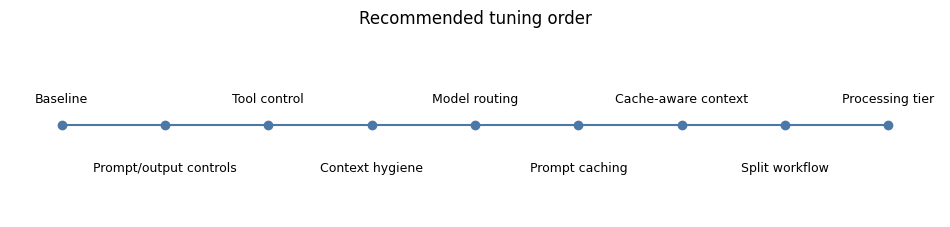

In [31]:
tuning_order = [
    "Baseline",
    "Prompt/output controls",
    "Tool control",
    "Context hygiene",
    "Model routing",
    "Prompt caching",
    "Cache-aware context",
    "Split workflow",
    "Processing tier",
]

fig, ax = plt.subplots(figsize=(12, 2.4))
ax.plot(range(len(tuning_order)), [1] * len(tuning_order), marker="o", color="#4C78A8")
for i, label in enumerate(tuning_order):
    ax.text(i, 1.03 if i % 2 == 0 else 0.94, label, ha="center", va="bottom" if i % 2 == 0 else "top", fontsize=9)
ax.set_xlim(-0.5, len(tuning_order) - 0.5)
ax.set_ylim(0.85, 1.15)
ax.axis("off")
ax.set_title("Recommended tuning order")
plt.show()

## Exercise

Extend the eval set with two real ticket categories from your support operation. For each category:

- define expected tools
- define escalation rules
- run the dry-run harness
- then run 5 to 10 live traces with `RUN_LIVE_API_CALLS=true`
- compare where live traces disagree with the dry-run assumptions

The most valuable output of this cookbook is a production dashboard that catches regressions when you change prompts, tools, models, or routing rules.

## Conclusion

Cost optimization for support agents works best as a measured sequence of small changes, not as a single model swap or prompt rewrite. Start by building a baseline that exposes where tokens, tool calls, latency, quality failures, and spend are going. Then tighten prompt and output controls, restrict tool use, reduce tool payloads, trim context, route simple work to smaller models, make stable prefixes cache-friendly, and move non-customer-facing work out of the synchronous path.

The main principle is to spend capability where it protects quality. A routine order-status question, a structured triage step, a policy-heavy refund dispute, and an offline QA tagger should not use the same model, context, tools, or latency tier. The optimized system should be cheaper because it is more disciplined, not because it blindly removes safeguards.

Before shipping changes, validate them with representative evals and trace metrics. Track quality score, policy compliance, action accuracy, escalation accuracy, tool-call count, token usage, cached-token volume, p50 and p95 latency, synchronous cost, async follow-up cost, and total cost per ticket. A configuration is only better if it lowers cost while preserving the support quality bar.
